# E14 · Simulation-based inference: Bayes when you can simulate but cannot write the likelihood

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | 2906 daily S&P 500 log-returns (2008-2019) · 114 years of Canadian lynx trappings on the Mackenzie River (1821-1934) |
| **You will learn** | What "likelihood-free" means and what it costs · rejection ABC in 15 lines of NumPy, calibrated against a known posterior · the two approximations (tolerance $\epsilon$, summary statistics) and how each one fails · `pm.Simulator` + `pm.sample_smc` (SMC-ABC) as they behave in PyMC 6 · the g-and-k distribution for heavy-tailed returns, checked against a numerical-likelihood posterior · Wood's synthetic likelihood for a noisy nonlinear population model · diagnostics that are specific to SBI: $\epsilon$ and summary sensitivity, SMC stage statistics, coverage tests and what they cannot see · where neural SBI has taken the field |

**E09** fitted a predator-prey ODE to pelt records. That simulator was *deterministic*: given
the parameters the trajectory is fixed, the likelihood is "trajectory plus Normal noise", and
NUTS works. This notebook is about what you do when the simulator is **stochastic all the way
down** - when the randomness is inside the dynamics, not painted on afterwards - and the
likelihood $p(y \mid \theta)$ is an integral over every path the hidden noise could have
taken. Agent-based models, stochastic population dynamics, epidemics on networks, queueing
systems, particle-physics detector simulations, distributions defined only by their quantile
function: for all of them *drawing* fake data at a given $\theta$ is a few lines of code, while
*evaluating* the probability of the data you actually have is intractable.

**Simulation-based inference (SBI)** replaces "evaluate the likelihood of the observed data"
with "simulate data and compare it with the observed data". The oldest and most transparent
version is **approximate Bayesian computation (ABC)**:

1. draw $\theta$ from the prior,
2. simulate a dataset $y^{\text{sim}} \sim p(\cdot \mid \theta)$,
3. keep $\theta$ if $y^{\text{sim}}$ looks like $y^{\text{obs}}$.

If "looks like" meant "is identical to", the kept $\theta$ would be exact posterior draws.
It cannot mean that for continuous data, so two approximations enter, and the whole craft
of ABC is managing them:

| Approximation | What you do | What it costs |
|---|---|---|
| **Summary statistics** $s(y)$ | compare a handful of numbers, not whole datasets | you get $p(\theta \mid s^{\text{obs}})$, not $p(\theta \mid y^{\text{obs}})$: information is lost unless $s$ is sufficient |
| **Tolerance** $\epsilon$ | accept when $\lVert s^{\text{sim}} - s^{\text{obs}} \rVert < \epsilon$ | the posterior is smeared towards the prior; shrinking $\epsilon$ drives the acceptance rate to zero |

Nothing here is exact and none of it should be presented as exact. The plan is therefore:
earn trust on a toy where the truth is known (section 1), then apply the tools to two real
problems, checking against an independent reference wherever one exists (sections 2 and 3).

A budget note: SBI burns simulations. To stay inside a few minutes every simulator below is
vectorised in NumPy, particle counts are modest (two SMC runs of 1000 particles per fit), and the expensive
checks are run on the toy. Each of those choices is flagged where it is made.

In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy.optimize
import scipy.stats as st

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

# pm.Simulator wraps a Python function; the Numba backend tells you so at every compile
warnings.filterwarnings("ignore", message=".*object mode.*")
NOTEBOOK_START = time.perf_counter()

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Rejection ABC from scratch, against a known posterior

### 1.1 · The tolerance $\epsilon$

The toy: $n = 40$ observations $y_i \sim \text{Normal}(\mu, 1)$ with prior
$\mu \sim \text{Normal}(0, 3)$. The exact posterior is conjugate, and the sample mean is a
**sufficient** statistic, so the only approximation in play is the tolerance.

Here is the entire algorithm. It is vectorised - all `n_sim` datasets are simulated in one
call - because that is what makes ABC affordable in Python.

In [2]:
N_TOY, TAU = 40, 3.0
y_toy = rng.normal(1.0, 1.0, N_TOY)

post_var = 1 / (1 / TAU**2 + N_TOY)
post_mean, post_sd = post_var * N_TOY * y_toy.mean(), np.sqrt(post_var)
print(f"exact posterior: mu ~ Normal({post_mean:.3f}, {post_sd:.3f})")


def rejection_abc(rng, s_obs, eps, n_sim=400_000):
    mu = rng.normal(0, TAU, n_sim)                         # 1. draw from the prior
    s_sim = rng.normal(mu[:, None], 1.0, (n_sim, N_TOY)).mean(axis=1)   # 2. simulate, summarise
    keep = np.abs(s_sim - s_obs) < eps                     # 3. keep the close ones
    return mu[keep], keep.mean()

exact posterior: mu ~ Normal(1.035, 0.158)


In [3]:
eps_grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
rows, abc_draws = [], {}
for eps in eps_grid:
    draws, acc = rejection_abc(rng, y_toy.mean(), eps)
    abc_draws[eps] = draws
    rows.append({"epsilon": eps, "accepted": len(draws), "acceptance rate": acc,
                 "ABC mean": draws.mean(), "ABC sd": draws.std()})
toy_eps = pd.DataFrame(rows).set_index("epsilon")
toy_eps["sd / exact sd"] = toy_eps["ABC sd"] / post_sd
toy_eps.round(4)

,accepted,acceptance rate,ABC mean,ABC sd,sd / exact sd
epsilon,,,,,
0.01,1016,0.0025,1.0318,0.1610,1.0195
0.03,3025,0.0076,1.0368,0.1612,1.0212
0.10,10128,0.0253,1.0359,0.1663,1.0529
0.30,29832,0.0746,1.0290,0.2352,1.4896
1.00,98624,0.2466,0.9944,0.5929,3.7553
3.00,261363,0.6534,0.7361,1.6071,10.1781


For this toy the $\epsilon$-error can be written down. Accepting when
$|\bar y^{\text{sim}} - \bar y^{\text{obs}}| < \epsilon$ is the same as observing
$\bar y^{\text{obs}}$ through extra uniform measurement noise of variance $\epsilon^2/3$.
Treating that noise as Gaussian, ABC targets the posterior of a model whose sampling variance
is $\sigma^2/n + \epsilon^2/3$ instead of $\sigma^2/n$:

$$
\text{sd}_{\text{ABC}}(\epsilon) \approx \left(\frac{1}{\tau^2} + \frac{1}{\sigma^2/n + \epsilon^2/3}\right)^{-1/2}
$$

That is the one formula worth remembering from this notebook: **the tolerance acts like
extra observation noise on the summaries**, so what matters is $\epsilon$ *relative to the
sampling standard deviation of the summary* ($\sigma/\sqrt{n} = 0.16$ here).

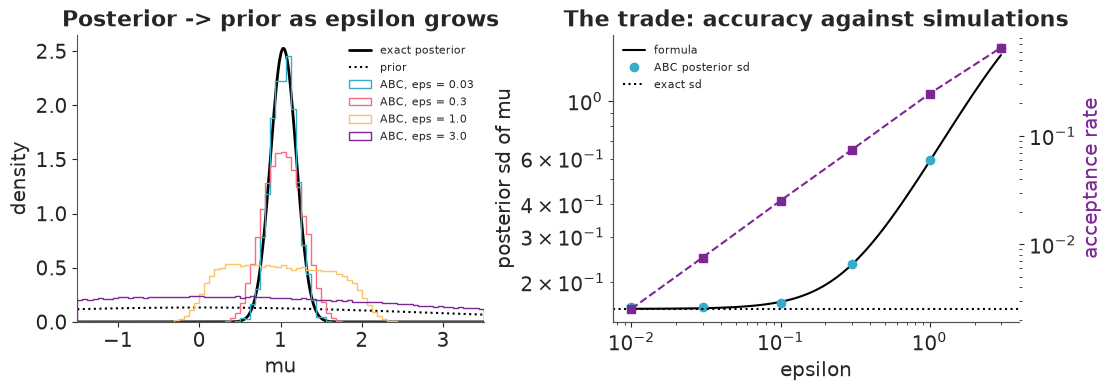

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
grid = np.linspace(-1.5, 3.5, 400)
ax = axes[0]
ax.plot(grid, st.norm.pdf(grid, post_mean, post_sd), "k", lw=2, label="exact posterior")
ax.plot(grid, st.norm.pdf(grid, 0, TAU), "k:", label="prior")
for eps, color in zip([0.03, 0.3, 1.0, 3.0], ["C0", "C1", "C2", "C3"]):
    ax.hist(abc_draws[eps], bins=np.linspace(-1.5, 3.5, 81), density=True, histtype="step", color=color,
            label=f"ABC, eps = {eps}")
ax.set(xlabel="mu", ylabel="density", xlim=(-1.5, 3.5), title="Posterior -> prior as epsilon grows")
ax.legend(fontsize=8)

ax = axes[1]
eps_fine = np.geomspace(0.01, 3, 100)
ax.plot(eps_fine, np.sqrt(1 / (1 / TAU**2 + 1 / (1 / N_TOY + eps_fine**2 / 3))), "k", label="formula")
ax.plot(toy_eps.index, toy_eps["ABC sd"], "o", color="C0", label="ABC posterior sd")
ax.axhline(post_sd, color="k", ls=":", label="exact sd")
ax.set(xscale="log", yscale="log", xlabel="epsilon", ylabel="posterior sd of mu")
ax2 = ax.twinx()
ax2.plot(toy_eps.index, toy_eps["acceptance rate"], "s--", color="C3")
ax2.set(yscale="log", ylabel="acceptance rate")
ax2.yaxis.label.set_color("C3")
ax2.grid(False)
ax.set_title("The trade: accuracy against simulations")
ax.legend(fontsize=8);

Read the table and the right-hand panel together:

- Once $\epsilon$ is well below the summary's own sampling sd (0.16) the ABC posterior is
  within a few percent of the exact one - and the acceptance rate is a fraction of a percent.
  In one dimension that is affordable. It will not stay affordable.
- At $\epsilon = 0.3$ (twice the sampling sd) the posterior is already about 1.5 times too
  wide; at $\epsilon = 3$ it is ten times too wide and on its way back to the prior (sd 3) -
  the mean has slid from 1.04 to 0.74 as well. Note what an over-large $\epsilon$ does **not** do: it does not make
  ABC confidently wrong here, it makes it *vague*. The $\epsilon$-error is conservative when
  the summaries are good. (It stops being harmless when the model is misspecified - section 2.)
- The formula tracks the simulation until $\epsilon$ is comparable to the prior width.

### 1.2 · The summary statistics

Now let both $\mu$ and $\sigma$ be unknown (`Normal(0, 3)` and `HalfNormal(3)` priors) and
compare four choices of summary. With several summaries the distance needs a scale; the
standard choice is to divide each summary by its prior-predictive standard deviation. We also
switch from a fixed $\epsilon$ to "keep the closest 0.2%", which is the same thing with
$\epsilon$ chosen by quantile - easier to budget.

The exact posterior is computed on a grid for reference.

In [5]:
y_toy2 = rng.normal(1.0, 2.0, N_TOY)
N_SIM = 1_000_000

mu_sim = rng.normal(0, 3, N_SIM)
sigma_sim = np.abs(rng.normal(0, 3, N_SIM))


def mad(Y):
    return np.median(np.abs(Y - np.median(Y, axis=1, keepdims=True)), axis=1)


SUMMARY_SETS = {
    "mean, log sd (sufficient)": lambda Y: np.column_stack([Y.mean(1), np.log(Y.std(1))]),
    "median, log MAD": lambda Y: np.column_stack([np.median(Y, 1), np.log(mad(Y))]),
    "min, max": lambda Y: np.column_stack([Y.min(1), Y.max(1)]),
    "mean only": lambda Y: Y.mean(1)[:, None],
}


def nearest(S_table, s_obs, scale, k):
    """Indices of the k simulations whose scaled summaries are closest to s_obs."""
    d = (((S_table - s_obs) / scale) ** 2).sum(axis=1)
    return np.argpartition(d, k)[:k]


# exact posterior on a grid
mu_g, sg_g = np.linspace(-1.5, 3.5, 300), np.linspace(1.0, 4.0, 300)
MG, SG = np.meshgrid(mu_g, sg_g, indexing="ij")
logp = (st.norm.logpdf(y_toy2[None, None, :], MG[..., None], SG[..., None]).sum(-1)
        + st.norm.logpdf(MG, 0, 3) + st.norm.logpdf(SG, 0, 3))
p_grid = np.exp(logp - logp.max())
p_grid /= p_grid.sum()
p_mu, p_sg = p_grid.sum(1), p_grid.sum(0)


def grid_moments(x, p):
    m = (x * p).sum()
    return m, np.sqrt(((x - m) ** 2 * p).sum())


rows = [{"summaries": "EXACT (grid)", "mu mean": grid_moments(mu_g, p_mu)[0], "mu sd": grid_moments(mu_g, p_mu)[1],
         "sigma mean": grid_moments(sg_g, p_sg)[0], "sigma sd": grid_moments(sg_g, p_sg)[1]}]
# Memory: a million datasets of 40 numbers is 320 MB and the summaries need temporaries of the same
# size, so simulate in chunks of 100,000 and keep only the summaries (a few MB per set).
CHUNK = 100_000
S_tables = {name: [] for name in SUMMARY_SETS}
for i in range(0, N_SIM, CHUNK):
    Y_chunk = rng.normal(mu_sim[i:i + CHUNK, None], sigma_sim[i:i + CHUNK, None], (CHUNK, N_TOY))
    for name, fn in SUMMARY_SETS.items():
        S_tables[name].append(fn(Y_chunk))
del Y_chunk
S_tables = {name: np.concatenate(parts) for name, parts in S_tables.items()}

toy_post = {}
for name, fn in SUMMARY_SETS.items():
    S = S_tables[name]
    keep = nearest(S, fn(y_toy2[None])[0], S.std(0), k=2000)
    toy_post[name] = (mu_sim[keep], sigma_sim[keep])
    rows.append({"summaries": name, "mu mean": mu_sim[keep].mean(), "mu sd": mu_sim[keep].std(),
                 "sigma mean": sigma_sim[keep].mean(), "sigma sd": sigma_sim[keep].std()})
pd.DataFrame(rows).set_index("summaries").round(3)

,mu mean,mu sd,sigma mean,sigma sd
summaries,,,,
EXACT (grid),0.940,0.346,2.187,0.254
"mean, log sd (sufficient)",0.937,0.355,2.188,0.265
"median, log MAD",1.307,0.461,2.352,0.467
"min, max",0.295,0.650,2.029,0.311
mean only,0.927,0.470,2.486,1.839


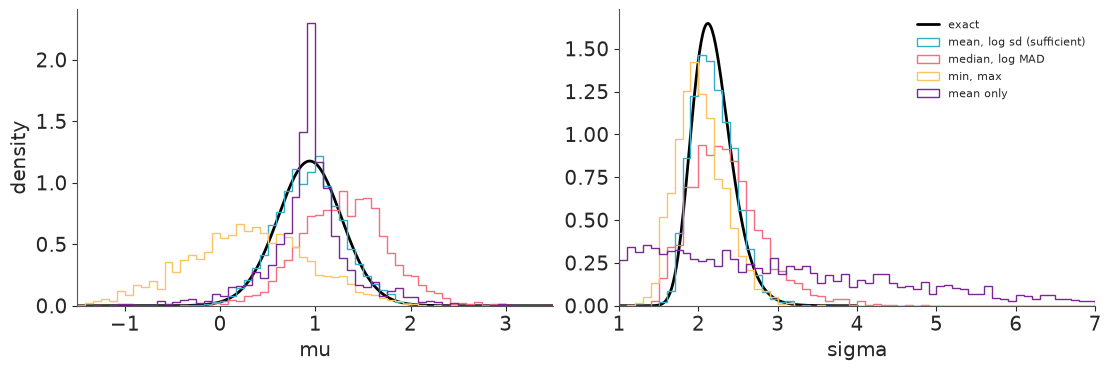

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, idx, xg, pg, lab in [(axes[0], 0, mu_g, p_mu, "mu"), (axes[1], 1, sg_g, p_sg, "sigma")]:
    ax.plot(xg, pg / (xg[1] - xg[0]), "k", lw=2, label="exact")
    for (name, draws), color in zip(toy_post.items(), ["C0", "C1", "C2", "C3"]):
        ax.hist(draws[idx], bins=np.linspace(xg[0], xg[-1] + (3 if idx else 0), 61), density=True,
                histtype="step", color=color, label=name)
    ax.set(xlabel=lab, xlim=(xg[0], xg[-1] + (3 if idx else 0)))
axes[0].set_ylabel("density")
axes[1].legend(fontsize=8);

Same data, same simulator, same number of simulations, same acceptance quantile - and four
different "posteriors":

- **Sufficient summaries** recover the exact posterior up to the $\epsilon$-error (a few
  percent of extra width at this budget).
- **Median and MAD** give a posterior that is about a third wider for $\mu$, nearly twice as
  wide for $\sigma$, and *centred somewhere else* (1.31 against 0.94 for $\mu$: this sample's
  median happens to sit above its mean). That is not a bug. Conditioning on different, less
  informative numbers gives a different, wider posterior. Robust summaries are not efficient;
  we will pay that price deliberately in section 2, where robustness matters more.
- **Min and max** give a *shifted and much wider* answer for $\mu$ (nearly twice the exact
  sd). The extremes of 40 draws are noisy functions of the parameters.
- **The mean alone** knows nothing about $\sigma$ - its "posterior" for $\sigma$ is essentially
  the HalfNormal(3) prior - and the ignorance about $\sigma$ leaks into $\mu$, whose posterior
  becomes a peaked, heavy-tailed scale mixture.

Every one of these is a perfectly valid posterior $p(\theta \mid s^{\text{obs}})$. None announces
that it is wider than it needs to be. **Nothing inside an ABC run tells you that your
summaries threw information away**; only a comparison with a better summary set (or a
known truth) does. Hold that thought for the coverage test in 1.4.

### 1.3 · The same thing in PyMC: `pm.Simulator` + `pm.sample_smc`

Rejection from the prior wastes almost every simulation once the posterior is much narrower
than the prior. **Sequential Monte Carlo ABC** fixes that by approaching the posterior in
stages, moving a population of particles with MCMC steps at each stage. PyMC packages it as:

- **`pm.Simulator(name, fn, *params, distance=, sum_stat=, epsilon=, observed=)`**, where
  `fn(rng, *params, size)` is any Python function returning simulated data. It has no
  density. Its "log-likelihood" is a *kernel*: one fresh simulation per evaluation, compared
  with the data through `distance="gaussian"`,
  $-\tfrac12 \sum_j \big((s_j^{\text{obs}} - s_j^{\text{sim}})/\epsilon_j\big)^2$
  (or `"laplace"`). `sum_stat` can be `"identity"`, `"sort"`, `"mean"`, `"median"` or a function.
- **`pm.sample_smc`**, which tempers that pseudo-likelihood: stage $t$ targets
  prior $\times$ kernel$^{\beta_t}$ with $\beta$ climbing from 0 to 1, each $\beta_t$ chosen so
  that the importance-sampling ESS stays at half the particles (`threshold=0.5`). Raising a
  Gaussian kernel to the power $\beta$ is the same as using tolerance $\epsilon/\sqrt{\beta}$ -
  so **the tempering ladder *is* a shrinking-tolerance schedule**, ending at the $\epsilon$
  you asked for. The default kernel is independent Metropolis-Hastings (`pm.smc.kernels.IMH`)
  with a multivariate-Normal proposal fitted to the particles; `pm.smc.kernels.MH` is a
  random walk.

A Gaussian kernel makes the formula of 1.1 *exact* for the toy, with $\epsilon^2$ in place of
$\epsilon^2/3$. That is a sharp test of the whole machine: PyMC's answer should match the
exact posterior *of the inflated-variance model*, not the true posterior.

In [7]:
EPS_TOY = 0.1
# pm.sample_smc is a multiprocess sampler: every chain is a worker process holding a copy of this
# kernel's memory. Two chains on two cores keeps the footprint (and the run time) down.
SMC_CHAINS = 2


def toy_simulator(rng, mu, size):
    return rng.normal(mu, 1.0, size=size)


with pm.Model() as toy_model:
    mu = pm.Normal("mu", 0, TAU)
    pm.Simulator("y", toy_simulator, mu, distance="gaussian", sum_stat="mean", epsilon=EPS_TOY, observed=y_toy)
    idata_toy = pm.sample_smc(draws=1000, chains=SMC_CHAINS, cores=2, random_seed=RANDOM_SEED, progressbar=False)

kernel_var = 1 / (1 / TAU**2 + 1 / (1 / N_TOY + EPS_TOY**2))
print(f"exact posterior                 : mean {post_mean:.3f}  sd {post_sd:.3f}")
print(f"theory for a Gaussian kernel    : mean {kernel_var * y_toy.mean() / (1 / N_TOY + EPS_TOY**2):.3f}"
      f"  sd {np.sqrt(kernel_var):.3f}")
print(f"pm.Simulator + pm.sample_smc    : mean {float(idata_toy.posterior['mu'].mean()):.3f}"
      f"  sd {float(idata_toy.posterior['mu'].std()):.3f}")
print("groups:", list(idata_toy.children))

Initializing SMC sampler...


Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics


exact posterior                 : mean 1.035  sd 0.158
theory for a Gaussian kernel    : mean 1.034  sd 0.187
pm.Simulator + pm.sample_smc    : mean 1.047  sd 0.185
groups: ['posterior', 'sample_stats', 'observed_data']


PyMC lands on the theoretical value for its kernel (to within the Monte Carlo error of 2000
particles), which is wider than the exact posterior by the amount the formula predicts. The machinery is right, and the $\epsilon$-error
is ours to manage.

Things about `pm.Simulator` in PyMC 6.3 that are not obvious from the docstring (all verified
here):

- The function receives each parameter as a NumPy array (shape `(1,)` when the data are a
  vector - not a Python float) and `size` equal to the shape of `observed`.
- The per-stage statistics `beta`, `accept_rate` and `log_marginal_likelihood` live in
  `idata.sample_stats` as **object arrays**: `(chain, stage)` when every chain took the same
  number of stages, but a 1-D `(chain,)` array *of lists* when they did not (each chain picks
  its own ladder). `smc_stages` below handles both. For a Simulator the
  "marginal likelihood" is that of the *kernel*; it depends on $\epsilon$ and is not a model
  evidence you can compare across summary sets.
- `ndim_supp=1` with scalar parameters fails (`NotImplementedError: _supp_shape_from_params`).
  Leave it at the default and simply return an array shaped like `observed`.
- Every likelihood evaluation is one Python call to your simulator for **one particle**. There
  is no vectorisation across particles, so a run costs draws x stages x MH-steps calls.
- Chains run in separate worker processes, each with a copy of the model. Never import JAX in the same process (see AUTHORING's
  gotchas); results are reproducible with `random_seed`.
- `distance="kullback_leibler"` is listed in the docstring but raises `NotImplementedError`.

### 1.4 · A coverage test - and the thing it cannot see

The question every approximate method must answer: *are my 90% intervals right 90% of the
time?* For SBI this is cheap to ask **because we own the simulator**: draw $\theta^*$ from the
prior, simulate data, run the inference, record where $\theta^*$ falls in the posterior. If the
posteriors are correct, the rank of $\theta^*$ among the posterior draws is uniform
(simulation-based calibration, Talts et al. 2018) and the 90% interval covers 90% of the time.

With rejection ABC it is nearly free: the table of one million simulations from 1.2 *is* a
sample from the joint $p(\theta, y)$, so hold out 300 rows as test cases with known truth and
run nearest-neighbour ABC for each against the rest. Three settings: a tight tolerance with
sufficient summaries, a sloppy tolerance, and a tight tolerance with the insufficient "mean
only" summary.

In [8]:
N_TEST, N_TABLE = 300, 300_000
S_full = S_tables["mean, log sd (sufficient)"][: N_TABLE + N_TEST]
table, tests = slice(0, N_TABLE), range(N_TABLE, N_TABLE + N_TEST)
scale_full = S_full[table].std(0)

settings = {
    "sufficient, keep 0.1%": (slice(0, 2), 300),
    "sufficient, keep 20%": (slice(0, 2), 60_000),
    "mean only, keep 0.1%": (slice(0, 1), 300),
}
cov_rows, ranks = [], {}
for name, (cols, k) in settings.items():
    hit, width, rk = [], [], []
    for i in tests:
        keep = nearest(S_full[table, cols], S_full[i, cols], scale_full[cols], k)
        lo, hi = np.quantile(mu_sim[keep], [0.05, 0.95])
        hit.append(lo < mu_sim[i] < hi)
        width.append(hi - lo)
        rk.append((mu_sim[keep] < mu_sim[i]).mean())
    ranks[name] = np.array(rk)
    cov_rows.append({"setting": name, "coverage of 90% interval for mu": np.mean(hit),
                     "median interval width": np.median(width)})
del S_tables                                             # memory: the big tables are no longer needed
pd.DataFrame(cov_rows).set_index("setting").round(3)

,coverage of 90% interval for mu,median interval width
setting,,
"sufficient, keep 0.1%",0.897,1.169
"sufficient, keep 20%",0.973,4.186
"mean only, keep 0.1%",0.880,1.472


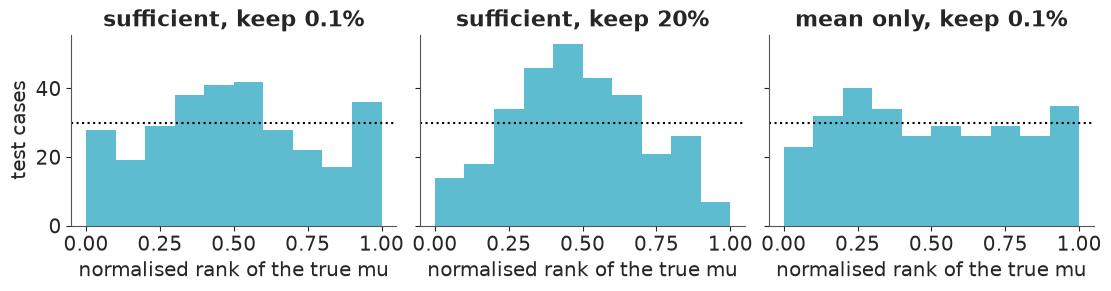

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for ax, (name, rk) in zip(axes, ranks.items()):
    ax.hist(rk, bins=10, range=(0, 1), color="C0", alpha=0.8)
    ax.axhline(N_TEST / 10, color="k", ls=":")
    ax.set(title=name, xlabel="normalised rank of the true mu")
axes[0].set_ylabel("test cases");

With 300 test cases a coverage estimate has a standard error of about 0.02, so read the table
with that in mind.

With ten bins, each bar is 30 give or take 5 from sampling noise alone.

- **Tight tolerance, sufficient summaries:** coverage 0.90 against a nominal 0.90, and a rank
  histogram with no structure beyond that noise (perhaps a slight excess in the middle, which
  is the direction the residual $\epsilon$-error would push). This is what "calibrated" looks
  like.
- **Sloppy tolerance:** the 90% intervals cover 97% of the time, are more than three times
  wider, and the ranks pile up in the middle - the signature of a posterior that is **too
  wide**. A coverage test catches the $\epsilon$-error.
- **Insufficient summary:** coverage is again close to nominal (0.88) and the ranks are flat,
  although the intervals are a quarter wider than with the sufficient pair. A coverage test is **blind to
  information loss**: $p(\theta \mid s)$ is a genuine posterior for whatever $s$ you chose, and genuine
  posteriors are calibrated. Calibration is necessary, not sufficient. To judge summaries you
  have to compare interval *widths* between summary sets, or compare with a reference.

That is the toolkit. Everything from here on uses real data, where no exact answer is
printed at the back of the book.

## 2 · Real application 1: the g-and-k distribution for S&P 500 returns

### 2.1 · Data and model

Daily returns are slightly skewed and very heavy-tailed. A flexible way to describe that is
to transform a standard Normal variable $z$:

$$
x = Q(z;\,A, B, g, k) = A + B\,\Big(1 + c \tanh\frac{g z}{2}\Big)\,(1 + z^2)^{k}\, z,
\qquad z \sim \text{Normal}(0, 1),\quad c = 0.8
$$

with location $A$, scale $B$, skewness $g$ and tail weight $k$ ($g = k = 0$ is the Normal).
Since $z = \Phi^{-1}(u)$ this *is* the quantile function, so simulating is one line and any
quantile - a value-at-risk, say - is a closed-form function of the parameters. But $Q$ cannot
be inverted in closed form, so there is **no density formula**. That combination made the
g-and-k family the standard test problem of the ABC literature (Allingham, King & Mengersen
2009; Drovandi & Pettitt 2011), and it is a sensible model for returns in its own right.

In [10]:
data.describe("sp500")
sp500 = data.load("sp500")
x_obs = 100 * sp500["change"].to_numpy()      # percent per day
N_OBS = len(x_obs)
print(f"\n{N_OBS} daily log-returns, {sp500.index[0].date()} to {sp500.index[-1].date()}")
print(f"mean {x_obs.mean():.3f}%  sd {x_obs.std():.2f}%  skewness {st.skew(x_obs):.2f}"
      f"  excess kurtosis {st.kurtosis(x_obs):.1f}  worst day {x_obs.min():.1f}%")

sp500: Daily close and log-return ('change').
  source: S&P 500 index daily closes (2008-2019), via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/SP500.csv

2906 daily log-returns, 2008-05-02 to 2019-11-14
mean 0.027%  sd 1.24%  skewness -0.39  excess kurtosis 11.6  worst day -9.5%


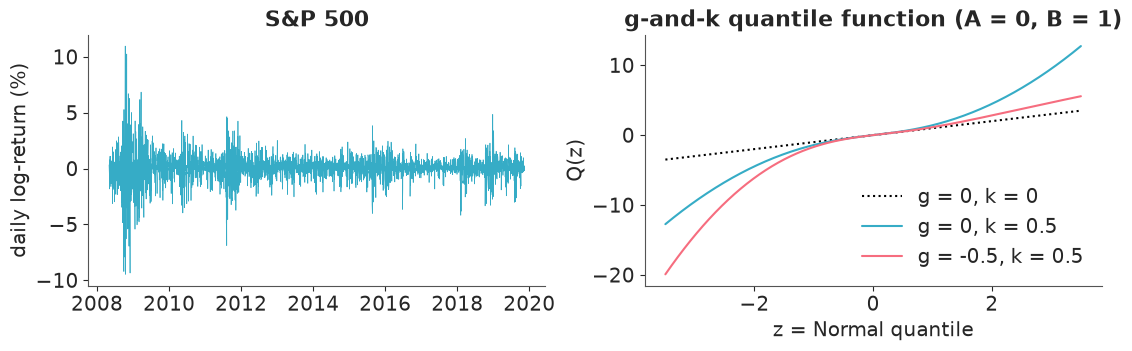

In [11]:
C_GK = 0.8


def gk_quantile(z, A, B, g, k):
    return A + B * (1 + C_GK * np.tanh(g * z / 2)) * (1 + z**2) ** k * z


fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(sp500.index, x_obs, lw=0.5)
axes[0].set(ylabel="daily log-return (%)", title="S&P 500")
zz = np.linspace(-3.5, 3.5, 200)
for (g, k), ls in zip([(0, 0), (0, 0.5), (-0.5, 0.5)], ["k:", "C0", "C1"]):
    axes[1].plot(zz, gk_quantile(zz, 0, 1, g, k), ls, label=f"g = {g}, k = {k}")
axes[1].set(xlabel="z = Normal quantile", ylabel="Q(z)", title="g-and-k quantile function (A = 0, B = 1)")
axes[1].legend();

An excess kurtosis near 12 and a worst day of almost -10% when the standard deviation is 1.2%:
this is not Normal data. The time series also shows the other well-known feature of returns,
volatility clustering. We model only the **marginal** distribution here and treat the days as
exchangeable, which understates the sampling variability of any summary (the effective number
of independent days is smaller than 2906). E12 and C07 model the clustering; here the point
is the inference method.

### 2.2 · Summaries, tolerance and priors

**Summaries.** A quantile-defined model suggests quantile summaries, and with 12 units of
excess kurtosis anything moment-based (sample skewness, sample kurtosis) would be dominated by
a handful of crisis days and have a huge simulation variance. The standard choice is the seven
**octiles** $E_1, \dots, E_7$ (the 12.5%, 25%, ..., 87.5% quantiles): robust, cheap, and between
them they carry location ($E_4$), scale ($E_6 - E_2$), asymmetry and tail-versus-shoulder
information. Hold on to one fact: the octiles only look at the **central 75%** of the data.

**Tolerance.** Section 1 said that $\epsilon$ matters relative to the sampling sd of each
summary, so we set $\epsilon_j = f \times \text{sd}(s_j)$, with the sd from a bootstrap of the
observed returns, and start at $f = 1$. By the formula of 1.1 that should inflate the posterior
*variance of what the summaries determine* by roughly a factor two - a known, stated cost.

**Priors**, in percent per day: $A \sim \text{Normal}(0, 1)$, $B \sim \text{HalfNormal}(2)$,
$g \sim \text{Normal}(0, 1)$, $k \sim \text{HalfNormal}(1)$.

In [12]:
OCTILE_P = np.arange(1, 8) / 8
TAIL_P = np.array([0.01, 0.05, 0.125, 0.25, 0.5, 0.75, 0.875, 0.95, 0.99])


def s_octiles(x):
    return np.quantile(x, OCTILE_P)


def s_tail_quantiles(x):
    return np.quantile(x, TAIL_P)


def s_robust_moments(x):
    """Location, scale, skewness and kurtosis measures built from octiles (Drovandi & Pettitt 2011)."""
    e = np.quantile(x, OCTILE_P)
    scale = e[5] - e[1]
    return np.array([e[3], scale, (e[5] + e[1] - 2 * e[3]) / scale, (e[6] - e[4] + e[2] - e[0]) / scale])


def bootstrap_sd(summary_fn, n_boot=1000):
    boot_rng = np.random.default_rng(RANDOM_SEED)
    return np.array([summary_fn(boot_rng.choice(x_obs, N_OBS)) for _ in range(n_boot)]).std(axis=0)


print("observed octiles      :", s_octiles(x_obs).round(3))
print("bootstrap sd of each  :", bootstrap_sd(s_octiles).round(3))

observed octiles      : [-0.978 -0.38  -0.123  0.065  0.276  0.549  1.043]


bootstrap sd of each  : [0.049 0.024 0.014 0.013 0.017 0.021 0.03 ]


**Prior predictive check.** Simulate from the prior and ask whether the observed summaries are
somewhere inside the cloud. With a simulator this is two lines.

In [13]:
N_PRIOR = 5000
prior_gk = np.column_stack([rng.normal(0, 1, N_PRIOR), np.abs(rng.normal(0, 2, N_PRIOR)),
                            rng.normal(0, 1, N_PRIOR), np.abs(rng.normal(0, 1, N_PRIOR))])
z = rng.standard_normal((N_PRIOR, 500))       # 500 days per prior draw is enough for a look
x_prior = gk_quantile(z, *prior_gk.T[:, :, None])
iqr_prior = np.subtract(*np.quantile(x_prior, [0.75, 0.25], axis=1))
q01_prior = np.quantile(x_prior, 0.01, axis=1)
iqr_obs, q01_obs = np.subtract(*np.quantile(x_obs, [0.75, 0.25])), np.quantile(x_obs, 0.01)
print(f"interquartile range: observed {iqr_obs:.2f}%, prior predictive 5-95%:"
      f" {np.quantile(iqr_prior, 0.05):.2f} to {np.quantile(iqr_prior, 0.95):.2f}")
print(f"1% quantile        : observed {q01_obs:.2f}%, prior predictive 5-95%:"
      f" {np.quantile(q01_prior, 0.05):.1f} to {np.quantile(q01_prior, 0.95):.1f}")

interquartile range: observed 0.93%, prior predictive 5-95%: 0.20 to 7.82
1% quantile        : observed -3.90%, prior predictive 5-95%: -148.4 to -0.2


The observed values sit inside the prior predictive range, which is wide (it allows 1% quantiles
of a hundred percent or more per day - far too generous for an equity index, but harmless: the
data will dominate). Wide priors do cost SMC-ABC some extra early stages.

### 2.3 · Fit with `pm.Simulator` + `pm.sample_smc`

The simulator returns the *summaries* of a full-size simulated dataset, and the observed data
handed to PyMC are the observed summaries. It must simulate all 2906 days: the summaries of a
smaller sample would be noisier than the observed ones and the posterior would be too wide.

In [14]:
def make_gk_simulator(summary_fn):
    def simulate(rng, A, B, g, k, size):
        A, B, g, k = (float(np.squeeze(v)) for v in (A, B, g, k))    # parameters arrive as arrays
        return summary_fn(gk_quantile(rng.standard_normal(N_OBS), A, B, g, k))
    return simulate


def fit_gk_abc(summary_fn, eps_factor, draws=1000):
    start = time.perf_counter()
    with pm.Model() as model:
        A = pm.Normal("A", 0, 1)
        B = pm.HalfNormal("B", 2)
        g = pm.Normal("g", 0, 1)
        k = pm.HalfNormal("k", 1)
        pm.Simulator("s", make_gk_simulator(summary_fn), A, B, g, k, distance="gaussian", sum_stat="identity",
                     epsilon=eps_factor * bootstrap_sd(summary_fn), observed=summary_fn(x_obs))
        idata = pm.sample_smc(draws=draws, chains=SMC_CHAINS, cores=2, random_seed=RANDOM_SEED, progressbar=False)
    idata.attrs["seconds"] = time.perf_counter() - start
    return idata


GK_VARS = ["A", "B", "g", "k"]
idata_oct = fit_gk_abc(s_octiles, eps_factor=1.0)
print(f"{idata_oct.attrs['seconds']:.0f} s")
az.summary(idata_oct, var_names=GK_VARS, ci_kind="hdi", ci_prob=0.94, round_to=3)

Initializing SMC sampler...


Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics


10 s


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
A,0.074,0.015,0.048,0.104,820.948,717.337,1.003,0.001,0.000
B,0.588,0.033,0.528,0.648,1200.738,638.953,1.003,0.001,0.001
g,-0.061,0.087,-0.238,0.083,825.381,546.849,1.005,0.003,0.002
k,0.471,0.087,0.307,0.632,624.344,487.368,1.005,0.004,0.003


`r_hat` and ESS here compare two *independent SMC runs* (PyMC calls them chains), so they
answer "do repeated runs agree?" - a useful check on the particle approximation, silent
about $\epsilon$ and the summaries. The SBI-specific view is the stage-by-stage record:

In [15]:
def smc_stages(idata):
    """Per-stage beta and MH acceptance rate as NaN-padded (chain, stage) float arrays."""
    out = []
    for name in ["beta", "accept_rate"]:
        rows = [np.asarray(list(row), dtype=float) for row in idata.sample_stats[name].values]
        padded = np.full((len(rows), max(len(r) for r in rows)), np.nan)
        for i, r in enumerate(rows):
            padded[i, : len(r)] = r
        out.append(padded)
    return out


def final_acceptance(idata):
    """MH acceptance rate in the last stage, averaged over chains."""
    acc = smc_stages(idata)[1]
    return float(np.mean([row[np.isfinite(row)][-1] for row in acc]))


beta_oct, acc_oct = smc_stages(idata_oct)
print("stages per chain:", np.isfinite(beta_oct).sum(axis=1), " final-stage acceptance:", round(final_acceptance(idata_oct), 3))
n0 = np.isfinite(beta_oct[0]).sum()
pd.DataFrame({"beta": beta_oct[0, :n0], "effective epsilon / sd": 1.0 / np.sqrt(beta_oct[0, :n0]),
              "MH acceptance rate": acc_oct[0, :n0]}).rename_axis("stage (chain 0)").round(4)

stages per chain: [10 11]  final-stage acceptance: 0.126


,beta,effective epsilon / sd,MH acceptance rate
stage (chain 0),,,
0,0.0001,106.7594,0.5955
1,0.0005,45.7042,0.5498
2,0.0020,22.3796,0.5787
3,0.0066,12.3375,0.5922
4,0.0176,7.5289,0.5482
5,0.0452,4.7053,0.4908
6,0.1058,3.0747,0.3968
7,0.2380,2.0496,0.3588
8,0.5142,1.3945,0.2441


The ladder starts at an effective tolerance around a hundred bootstrap sd's - anything the
prior proposes is "close enough" - and roughly halves it at each stage. The Metropolis
acceptance rate falls as the tolerance tightens, because a proposed particle is accepted only
if its *single* noisy simulation lands near the observed summaries; by the last stage only
about one proposal in eight does. Remember that trend.

### 2.4 · An honesty check: the numerical-likelihood posterior

"No closed-form density" is not "no density". For a quantile-defined model
$f(x) = \phi(z) / Q'(z)$ at $z = Q^{-1}(x)$, and $Q^{-1}$ can be computed numerically: tabulate
the monotone function $Q$ on a fine grid, interpolate, and polish with two Newton steps
(Rayner & MacGillivray 2002 fitted the family this way). That gives a log-likelihood costing
under a millisecond for all 2906 days, which a plain random-walk Metropolis sampler can use.
So here, unusually, we can compare the ABC posterior with the real one on the full data.

In [16]:
Z_GRID = np.linspace(-10, 10, 2001)


def gk_dquantile(z, A, B, g, k):
    t, w = np.tanh(g * z / 2), 1 + z**2
    return B * w**k * ((1 + C_GK * t) * (1 + 2 * k * z**2 / w) + C_GK * g * z / 2 * (1 - t**2))


def gk_inverse(x, A, B, g, k):
    """z such that Q(z) = x, or None if Q is not increasing / x is off the grid."""
    q = gk_quantile(Z_GRID, A, B, g, k)
    if np.any(np.diff(q) <= 0) or x.min() < q[0] or x.max() > q[-1]:
        return None
    z = np.interp(x, q, Z_GRID)
    for _ in range(2):
        z = z - (gk_quantile(z, A, B, g, k) - x) / gk_dquantile(z, A, B, g, k)
    return z


def gk_logpost(theta):
    A, B, g, k = theta
    if B <= 0 or k < 0:
        return -np.inf
    z = gk_inverse(x_obs, A, B, g, k)
    if z is None:
        return -np.inf
    loglik = np.sum(-0.5 * z**2 - 0.5 * np.log(2 * np.pi) - np.log(gk_dquantile(z, A, B, g, k)))
    return loglik - 0.5 * A**2 - 0.5 * (B / 2) ** 2 - 0.5 * g**2 - 0.5 * k**2     # same priors as the ABC model


def random_walk_metropolis(logp, start, cov, n_iter, rng):
    d = len(start)
    L = np.linalg.cholesky(cov * 2.38**2 / d)
    theta, lp = np.array(start, float), logp(start)
    out, n_acc = np.empty((n_iter, d)), 0
    for i in range(n_iter):
        prop = theta + L @ rng.standard_normal(d)
        lp_prop = logp(prop)
        if np.log(rng.random()) < lp_prop - lp:
            theta, lp, n_acc = prop, lp_prop, n_acc + 1
        out[i] = theta
    return out, n_acc / n_iter


def numerical_hessian(f, x0, h=1e-3):
    d = len(x0)
    H, I = np.zeros((d, d)), np.eye(d) * h
    for i in range(d):
        for j in range(d):
            H[i, j] = (f(x0 + I[i] + I[j]) - f(x0 + I[i] - I[j]) - f(x0 - I[i] + I[j]) + f(x0 - I[i] - I[j])) / (4 * h * h)
    return H


start = time.perf_counter()
opt = scipy.optimize.minimize(lambda th: -gk_logpost(th), [0.05, 0.6, -0.1, 0.4], method="Nelder-Mead",
                              options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 4000})
laplace_cov = np.linalg.inv(numerical_hessian(lambda th: -gk_logpost(th), opt.x))
chains, acc_rates = [], []
for c in range(4):
    out, acc = random_walk_metropolis(gk_logpost, opt.x, laplace_cov, 4000, np.random.default_rng(RANDOM_SEED + c))
    chains.append(out[1000:])
    acc_rates.append(acc)
chains = np.array(chains)
idata_lik = az.from_dict({"posterior": {v: chains[:, :, i] for i, v in enumerate(GK_VARS)}})
print(f"{time.perf_counter() - start:.0f} s, Metropolis acceptance rates {np.round(acc_rates, 2)}")
az.summary(idata_lik, ci_kind="hdi", ci_prob=0.94, round_to=3)

6 s, Metropolis acceptance rates [0.31 0.3  0.3  0.3 ]


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
A,0.067,0.013,0.042,0.091,620.949,878.141,1.002,0.001,0.000
B,0.563,0.017,0.530,0.593,897.983,1340.488,1.003,0.001,0.000
g,-0.086,0.031,-0.146,-0.029,733.513,1118.218,1.005,0.001,0.001
k,0.544,0.024,0.500,0.588,745.404,1183.197,1.008,0.001,0.000


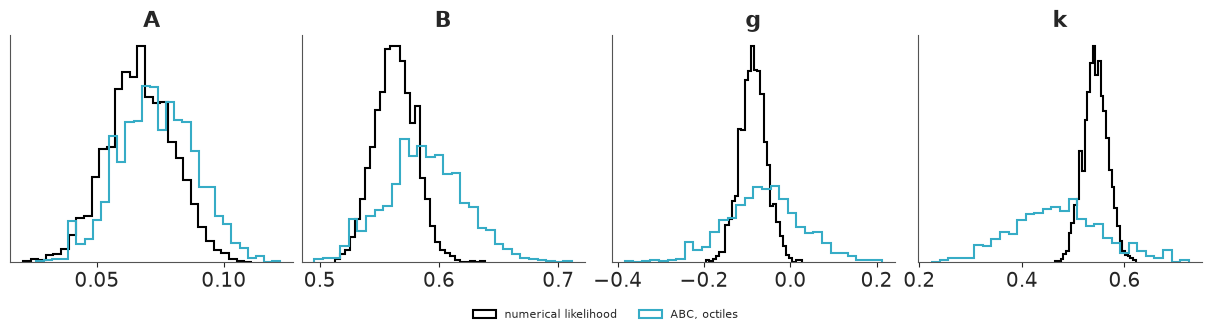

In [17]:
def draws_of(idata):
    return np.column_stack([idata.posterior[v].values.ravel() for v in GK_VARS])


def compare_posteriors(fits):
    fig, axes = plt.subplots(1, 4, figsize=(12, 2.9))
    for ax, j in zip(axes, range(4)):
        for (label, idata), color in zip(fits.items(), ["k", "C0", "C1", "C2", "C3"]):
            d = draws_of(idata)[:, j]
            ax.hist(d, bins=30, density=True, histtype="step", color=color, label=label, lw=1.5)
        ax.set(title=GK_VARS[j], yticks=[])
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(fits), fontsize=8, bbox_to_anchor=(0.5, -0.12))
    return fig


compare_posteriors({"numerical likelihood": idata_lik, "ABC, octiles": idata_oct});

In [18]:
def width_table(fits):
    rows = {}
    for label, idata in fits.items():
        d = draws_of(idata)
        rows[label] = {f"{v} {stat}": val for j, v in enumerate(GK_VARS)
                       for stat, val in [("mean", d[:, j].mean()), ("sd", d[:, j].std())]}
    return pd.DataFrame(rows).T.round(3)


width_table({"numerical likelihood": idata_lik, "ABC, octiles": idata_oct})

,A mean,A sd,B mean,B sd,g mean,g sd,k mean,k sd
numerical likelihood,0.067,0.013,0.563,0.017,-0.086,0.031,0.544,0.024
"ABC, octiles",0.074,0.015,0.588,0.033,-0.061,0.087,0.471,0.087


Report this honestly, because it is the most important table in the notebook:

- The two posteriors **agree on location and scale** ($A$, $B$) to within the ABC
  uncertainty, and ABC's intervals contain the likelihood-based estimates for $g$ and $k$ too.
  ABC is not *wrong*.
- But the ABC posterior is **far wider** where it matters: about three times wider for the
  skewness $g$ and nearly four times wider for the tail weight $k$. A factor of $\sqrt2$ is the
  $\epsilon$-error we signed up for. The rest is information loss: the full likelihood sees all
  2906 returns including the crash days, the octiles see the middle three quarters.
- The ABC estimate of $k$ is also *lower* (about 0.47 against 0.54): the body of the
  distribution suggests lighter tails than the tails themselves do. That is a hint of model
  misfit - a single $k$ cannot quite serve both - and it will matter for tail risk.

### 2.5 · Sensitivity to $\epsilon$

The obvious response to "too wide" is to halve the tolerance. Same model, $f = 0.5$:

In [19]:
idata_oct_tight = fit_gk_abc(s_octiles, eps_factor=0.5)
print(f"{idata_oct_tight.attrs['seconds']:.0f} s")
az.summary(idata_oct_tight, var_names=GK_VARS, ci_kind="hdi", ci_prob=0.94, round_to=3)

Initializing SMC sampler...


Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


10 s


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
A,0.069,0.011,0.053,0.089,43.961,12.462,1.041,0.002,0.001
B,0.581,0.023,0.526,0.620,77.159,74.744,1.019,0.003,0.002
g,-0.065,0.054,-0.145,0.050,28.268,60.420,1.068,0.011,0.004
k,0.486,0.063,0.378,0.596,52.823,30.179,1.061,0.009,0.005


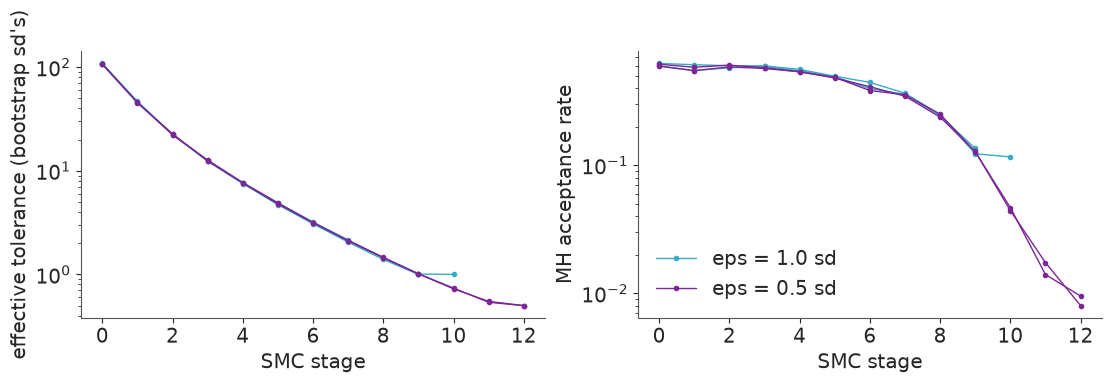

In [20]:
beta_tight, acc_tight = smc_stages(idata_oct_tight)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
for beta, acc, f, color in [(beta_oct, acc_oct, 1.0, "C0"), (beta_tight, acc_tight, 0.5, "C3")]:
    for c in range(len(beta)):                       # one line per chain (independent SMC run)
        axes[0].plot(f / np.sqrt(beta[c]), "o-", ms=3, lw=1, color=color, label=f"eps = {f} sd" if c == 0 else None)
        axes[1].plot(acc[c], "o-", ms=3, lw=1, color=color, label=f"eps = {f} sd" if c == 0 else None)
axes[0].set(yscale="log", xlabel="SMC stage", ylabel="effective tolerance (bootstrap sd's)")
axes[1].set(yscale="log", xlabel="SMC stage", ylabel="MH acceptance rate")
axes[1].legend();

This is the characteristic failure of ABC, and PyMC's own warnings flag it: with $f = 0.5$ the
acceptance rate in the final stages collapses to around one percent or less, the mutation
step can no longer move the particles, the population degenerates into copies of a few
ancestors, and the independent runs stop agreeing (`r_hat` well above 1.01, ESS in the tens). The
narrower posterior it reports is not to be trusted - some of that narrowness is particle
collapse. Why so brutal? Seven summaries must *all* land within half a standard deviation of
their targets in a single simulation; the chance of that falls geometrically with the number
of summaries. **This is ABC's curse of dimensionality, and it lives in the summaries, not in
the parameters.**

The remedies are more particles and more MH steps (linear cost for slowly diminishing
returns), fewer or better summaries, post-hoc regression adjustment of the accepted draws
(Beaumont, Zhang & Balding 2002), or a method that does not use a tolerance at all (section 3).
We keep $f = 1$ and turn to the question that matters more.

### 2.6 · Sensitivity to the summaries

Two alternatives to the octiles, both at $f = 1$:

- the four **robust moment** measures built from the octiles (one per parameter - fewer
  summaries, so a friendlier acceptance rate);
- **nine quantiles reaching into the tails** (1%, 5%, the octiles' 12.5-87.5% core, 95%, 99%),
  because we care about tail risk and the octiles cannot see it.

In [21]:
idata_rob = fit_gk_abc(s_robust_moments, eps_factor=1.0)
idata_tail = fit_gk_abc(s_tail_quantiles, eps_factor=1.0)
print(f"robust moments {idata_rob.attrs['seconds']:.0f} s, tail quantiles {idata_tail.attrs['seconds']:.0f} s")
print("final-stage MH acceptance:", {name: round(final_acceptance(i), 3) for name, i in
                                     [("octiles", idata_oct), ("robust moments", idata_rob), ("tail quantiles", idata_tail)]})
print("max r_hat:", {name: round(float(az.summary(i, var_names=GK_VARS)["r_hat"].max()), 3) for name, i in
                     [("octiles", idata_oct), ("robust moments", idata_rob), ("tail quantiles", idata_tail)]})

gk_fits = {"numerical likelihood": idata_lik, "ABC, octiles": idata_oct,
           "ABC, robust moments": idata_rob, "ABC, tail quantiles": idata_tail}
width_table(gk_fits)

Initializing SMC sampler...


Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing SMC sampler...


Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


robust moments 8 s, tail quantiles 11 s
final-stage MH acceptance: {'octiles': 0.126, 'robust moments': 0.211, 'tail quantiles': 0.075}
max r_hat: {'octiles': 1.005, 'robust moments': 1.004, 'tail quantiles': 1.01}


,A mean,A sd,B mean,B sd,g mean,g sd,k mean,k sd
numerical likelihood,0.067,0.013,0.563,0.017,-0.086,0.031,0.544,0.024
"ABC, octiles",0.074,0.015,0.588,0.033,-0.061,0.087,0.471,0.087
"ABC, robust moments",0.064,0.018,0.574,0.030,0.152,0.151,0.500,0.070
"ABC, tail quantiles",0.076,0.018,0.571,0.029,-0.129,0.048,0.507,0.046


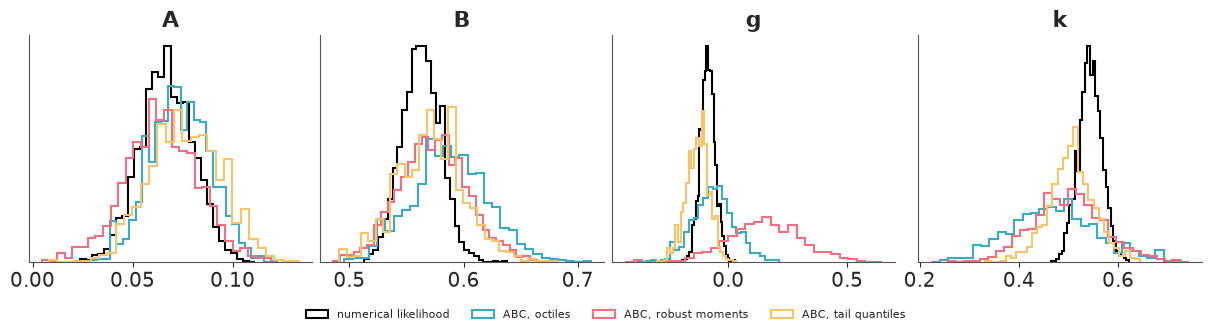

In [22]:
compare_posteriors(gk_fits);

Three summary sets, three different answers about skewness:

- The **robust moments** say $g$ is probably *positive*; the likelihood says it is clearly
  *negative*. Both are right about what they look at. The octile skewness measure is
  $(E_6 + E_2 - 2E_4)/(E_6 - E_2)$, which for these data is slightly positive: between the
  quartiles, returns lean to the right (many small gains). The left skew of equity returns lives
  in the tails (rare large losses), where that measure never looks.
- The **tail quantiles** pull $g$ firmly negative and move $k$ up, giving the ABC posterior
  closest to the likelihood-based one and the narrowest for $g$ and $k$ - though still about
  twice as wide as the reference for $k$. Nine summaries have a price, as 2.5 predicted: the
  final-stage acceptance rate is the lowest of the three (under 8%) and `r_hat` between the two
  runs is at the 1.01 borderline. Four summaries give the healthiest sampler (21%).
- $A$ and $B$ barely care.

If the g-and-k family were the true data-generating process, every summary set would give a
posterior centred near the same place, differing only in width (as in the toy). When the
model is **misspecified** - and a one-parameter skewness cannot be right-leaning in the
middle and left-leaning in the tails - **the summaries decide which features of the data the
model is asked to reproduce**. That is a liability if you chose them carelessly, and a tool if
you chose them on purpose: a risk manager *wants* the fit to privilege the tails. A full
likelihood makes that choice for you, silently.

### 2.7 · Posterior predictive checks and tail risk

For comparison, fit the two usual suspects by NUTS: a Normal and a Student-t.

In [23]:
with pm.Model() as normal_model:
    mu = pm.Normal("mu", 0, 1)
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("x", mu, sigma, observed=x_obs)
    idata_normal = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

with pm.Model() as t_model:
    mu = pm.Normal("mu", 0, 1)
    sigma = pm.HalfNormal("sigma", 2)
    nu = pm.Gamma("nu", 2, 0.1)
    pm.StudentT("x", nu=nu, mu=mu, sigma=sigma, observed=x_obs)
    idata_t = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

az.summary(idata_t, ci_kind="hdi", ci_prob=0.94, round_to=3)

NUTS[nutpie]: [mu, sigma]


NUTS[nutpie]: [mu, sigma, nu]


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.083,0.014,0.058,0.110,4281.342,3062.739,1.002,0.000,0.000
sigma,0.603,0.017,0.573,0.634,1851.277,2207.405,1.000,0.000,0.000
nu,2.118,0.111,1.930,2.339,1899.061,2241.385,1.001,0.003,0.002


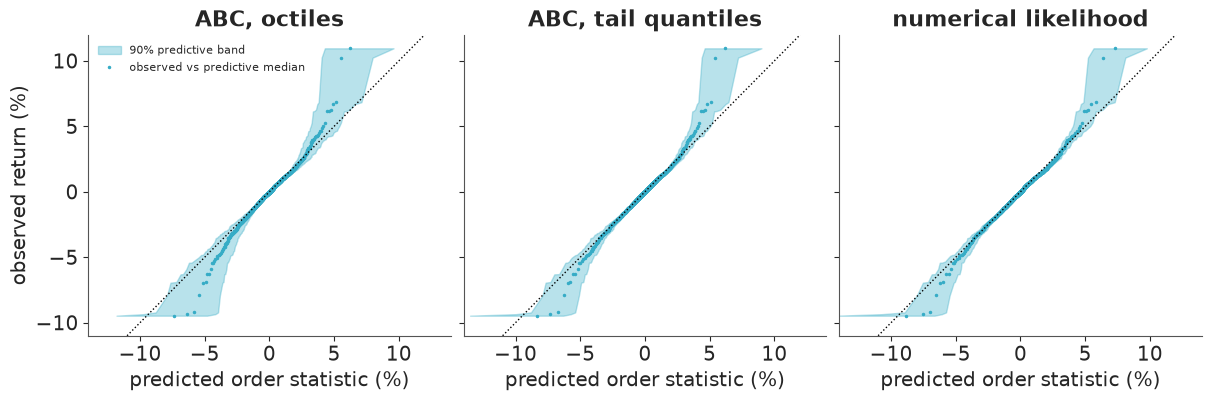

In [24]:
def qq_band(theta_draws, n_rep=300):
    """Posterior predictive 5-50-95% band of every order statistic of a dataset of N_OBS returns."""
    idx = rng.choice(len(theta_draws), n_rep, replace=False)
    z = np.sort(rng.standard_normal((n_rep, N_OBS)), axis=1)      # Q is increasing, so sorting z sorts x
    return np.quantile(gk_quantile(z, *theta_draws[idx].T[:, :, None]), [0.05, 0.5, 0.95], axis=0)


x_sorted = np.sort(x_obs)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharex=True, sharey=True)
for ax, label in zip(axes, ["ABC, octiles", "ABC, tail quantiles", "numerical likelihood"]):
    lo, mid, hi = qq_band(draws_of(gk_fits[label]))
    ax.fill_betweenx(x_sorted, lo, hi, color="C0", alpha=0.35, label="90% predictive band")
    ax.plot(mid, x_sorted, ".", ms=3, color="C0", label="observed vs predictive median")
    ax.plot([-12, 12], [-12, 12], "k:", lw=1)
    ax.set(title=label, xlabel="predicted order statistic (%)", xlim=(-14, 14), ylim=(-11, 12))
axes[0].set_ylabel("observed return (%)")
axes[0].legend(fontsize=8, loc="upper left");

In [25]:
def gk_cdf(x, theta):
    z = gk_inverse(np.atleast_1d(np.asarray(x, float)), *theta)
    return np.full(np.size(x), np.nan) if z is None else st.norm.cdf(z)


def gk_tail_table(theta_draws, n_draws=400):
    idx = rng.choice(len(theta_draws), n_draws, replace=False)
    th = theta_draws[idx]
    cdf = np.array([gk_cdf(THRESHOLDS, t) for t in th])
    var = np.array([gk_quantile(st.norm.ppf(VAR_LEVELS), *t) for t in th])
    return cdf, var


THRESHOLDS = np.array([-5.0, -3.0, 3.0, 5.0])
VAR_LEVELS = np.array([0.001, 0.01])


def fmt(draws):
    lo, hi = np.nanquantile(draws, [0.03, 0.97], axis=0)
    return [f"{m:.2f} [{a:.2f}, {b:.2f}]" for m, a, b in zip(np.nanmean(draws, axis=0), lo, hi)]


post_n = az.extract(idata_normal, num_samples=400, random_seed=RANDOM_SEED)
post_t = az.extract(idata_t, num_samples=400, random_seed=RANDOM_SEED)
model_cdf = {
    "Normal": (st.norm.cdf(THRESHOLDS[None], post_n["mu"].values[:, None], post_n["sigma"].values[:, None]),
               st.norm.ppf(VAR_LEVELS[None], post_n["mu"].values[:, None], post_n["sigma"].values[:, None])),
    "Student-t": (st.t.cdf(THRESHOLDS[None], post_t["nu"].values[:, None], post_t["mu"].values[:, None], post_t["sigma"].values[:, None]),
                  st.t.ppf(VAR_LEVELS[None], post_t["nu"].values[:, None], post_t["mu"].values[:, None], post_t["sigma"].values[:, None])),
}
for label in ["ABC, octiles", "ABC, tail quantiles", "numerical likelihood"]:
    model_cdf[f"g-and-k ({label})"] = gk_tail_table(draws_of(gk_fits[label]))

rows = {"observed": [str(np.sum(x_obs < -5)), str(np.sum(x_obs < -3)), str(np.sum(x_obs > 3)), str(np.sum(x_obs > 5)),
                     f"{np.quantile(x_obs, 0.001):.2f}", f"{np.quantile(x_obs, 0.01):.2f}"]}
for label, (cdf, var) in model_cdf.items():
    expected_days = N_OBS * np.column_stack([cdf[:, 0], cdf[:, 1], 1 - cdf[:, 2], 1 - cdf[:, 3]])
    rows[label] = fmt(expected_days) + fmt(var)
pd.DataFrame(rows, index=["days below -5%", "days below -3%", "days above +3%", "days above +5%",
                          "0.1% quantile", "1% quantile"]).T

,days below -5%,days below -3%,days above +3%,days above +5%,0.1% quantile,1% quantile
observed,14,56,38,9,-8.05,-3.90
Normal,"0.07 [0.04, 0.11]","21.05 [16.75, 25.57]","23.56 [19.25, 27.82]","0.09 [0.05, 0.12]","-3.80 [-3.91, -3.68]","-2.85 [-2.94, -2.76]"
Student-t,"17.02 [13.39, 21.64]","46.96 [39.91, 55.38]","52.45 [45.30, 60.88]","18.23 [14.33, 22.91]","-11.81 [-14.55, -9.85]","-3.83 [-4.26, -3.49]"
"g-and-k (ABC, octiles)","7.99 [0.51, 25.79]","44.10 [14.35, 87.08]","35.92 [13.84, 63.14]","4.37 [0.30, 12.98]","-6.00 [-9.21, -3.97]","-3.44 [-4.79, -2.56]"
"g-and-k (ABC, tail quantiles)","10.76 [5.08, 18.10]","54.38 [38.51, 72.41]","31.73 [19.26, 45.37]","3.05 [0.79, 6.73]","-6.70 [-8.00, -5.56]","-3.75 [-4.29, -3.27]"
g-and-k (numerical likelihood),"11.55 [7.85, 16.03]","56.63 [46.45, 67.42]","42.46 [33.92, 51.64]","5.61 [3.49, 8.33]","-6.85 [-7.62, -6.17]","-3.81 [-4.14, -3.52]"


(Posterior mean and 94% interval; "days" are expected counts in 2906 trading days.)

- The **Normal** is hopeless in the tails - it expects essentially no 5% days where there were
  14 down and 9 up, and its 1% value-at-risk is a full percentage point too optimistic.
- The **Student-t** fixes the 1% quantile, but its estimated $\nu$ of about 2 (barely finite
  variance) makes the far tail *too* heavy: being symmetric, it predicts twice the observed
  number of +5% days, and its 0.1% quantile (about -12%) is well beyond the observed -8%.
- The **g-and-k** fits all track the body well. With octile summaries the 1% quantile is centred
  too high (-3.4 against an observed -3.9) and very uncertain - the QQ band fans out beyond
  $\pm 3\%$, as it must when the fit has never seen the tails - and the intervals for the tail
  counts are wide enough to include almost anything. With tail quantiles among the summaries
  the intervals tighten around the observed numbers of $\pm 3\%$ and -5% days, and the 1% quantile
  (-3.75, interval about one point wide) is estimated nearly as well as by the full likelihood
  (-3.81, interval 0.6 wide).
- Every g-and-k version is too light in the far tail: the observed nine +5% days and the 0.1%
  quantile of -8% lie outside even the likelihood-based intervals, and in the QQ plots the most
  extreme days bend away from the diagonal on both sides. Those days are the volatility
  clusters of 2008-09 and 2011, which no i.i.d. model generates in the right numbers. That is a
  limit of the *model*, not of ABC.

What ABC bought here: a usable posterior, in about ten seconds per run, for a model with no density,
with summaries chosen to match the purpose. What it cost: intervals two to four times wider
than the likelihood would give, a tolerance that cannot be pushed much lower at this particle
budget, and a result that depends on the summaries - which we only know *because we checked*.

## 3 · Real application 2: a stochastic population model for the Canadian lynx

### 3.1 · Data and model

The long Mackenzie River record: 114 years of lynx trappings, one of the most analysed time
series in statistics, famous for its roughly ten-year cycle. Only the predator is observed
(E09 had both species, but for 21 years).

lynx_long: Annual Canadian lynx trappings on the Mackenzie River, 1821-1934 (114 years, predator only).
  source: Brockwell & Davis (1991) / Campbell & Walker (1977), via R `datasets::lynx`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/datasets/lynx.csv


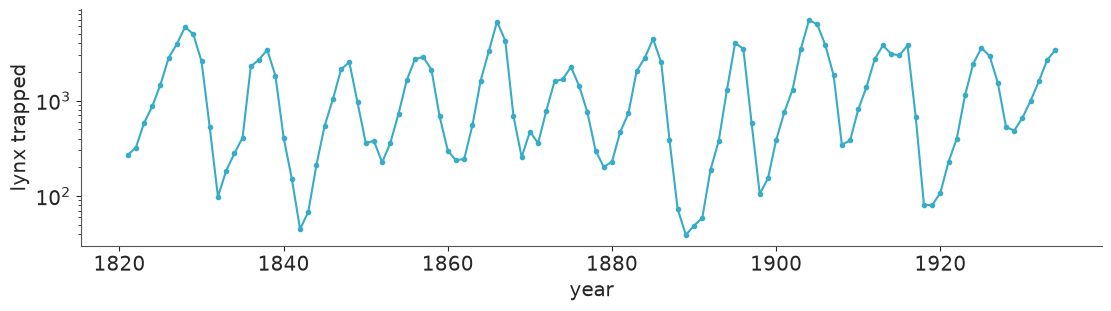

In [26]:
data.describe("lynx_long")
lynx = data.load("lynx_long")
y_lynx = lynx["value"].to_numpy(float)
T_LYNX = len(y_lynx)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(lynx["time"], y_lynx, "o-", ms=3)
ax.set(yscale="log", xlabel="year", ylabel="lynx trapped");

The model class is Wood's (2010): a discrete-time population map with **process noise inside
the dynamics** and Poisson observation noise,

$$
N_{t+1} = N_t \exp\!\Big[r\Big(1 - \frac{w_0 N_t + w_1 N_{t-1} + w_2 N_{t-2}}{K}\Big) + \sigma e_t\Big],
\qquad e_t \sim \text{Normal}(0,1), \qquad y_t \sim \text{Poisson}(N_t).
$$

With $w = (1, 0, 0)$ this is the **stochastic Ricker map**, Wood's example: growth rate $r$,
carrying capacity $K$ (in units of trapped animals, which absorbs the unknown trapping
fraction), environmental noise $\sigma$. The weights $w$ (non-negative, summing to one) let the
density dependence act with a **delay** of one or two years. A delay is the single-species
stand-in for an unobserved interaction: lynx numbers are limited by hares, and the hares'
numbers reflect how many lynx were eating them a year or two ago. Linear stability analysis
says a pure lag-2 model starts to cycle with period 10 at $r = 0.62$; the undelayed Ricker
map can only flip with period 2 (from $r = 2$) and turns chaotic near $r = 2.7$.

Why is this likelihood-free territory? The likelihood is a 114-dimensional integral over the
hidden noise path. It can be attacked with particle filters, but near-chaotic dynamics make
it worse than expensive - they make it **useless as a function of $\theta$**.

### 3.2 · Jagged likelihood, smooth summaries

Take the Ricker map in Wood's chaotic regime ($r = 3.8$, $\sigma = 0.3$, $K = 38$), simulate
one "observed" series, and look along a slice in $r$ at two things: the log-probability of
that series when the noise path $e_{1:T}$ is *held fixed* (what a naive likelihood or any
trajectory-matching method sees), and a smooth function of **summary statistics** (defined in
the next cell, the *synthetic likelihood* of 3.4).

In [27]:
def simulate_population(rng, r, K, sigma, w, T=T_LYNX, burn=60, noise=None):
    """Vectorised over n parameter sets: r, K, sigma have shape (n,), w has shape (n, 3). Returns (n, T) counts."""
    n = len(r)
    e = rng.standard_normal((burn + T, n)) if noise is None else noise
    N0, N1, N2 = K.copy(), K.copy(), K.copy()
    out = np.empty((n, T))
    for t in range(burn + T):
        density = (w[:, 0] * N0 + w[:, 1] * N1 + w[:, 2] * N2) / K
        N_new = np.clip(N0 * np.exp(r * (1 - density) + sigma * e[t]), 1e-6, 1e9)
        N2, N1, N0 = N1, N0, N_new
        if t >= burn:
            out[:, t - burn] = N0
    return rng.poisson(out).astype(float), out


ACF_LAGS = np.arange(1, 9)
SUMMARY_NAMES = ["mean log", "log sd log", "skew log"] + [f"acf {l}" for l in ACF_LAGS]


def population_summaries(Y):
    """(n, T) counts -> (n, 11) summaries of log(y + 1): mean, log sd, skewness, autocorrelation at lags 1-8."""
    L = np.log(Y + 1.0)
    m = L.mean(axis=1)
    c = L - m[:, None]
    v = (c**2).mean(axis=1) + 1e-12
    acf = np.stack([(c[:, l:] * c[:, :-l]).mean(axis=1) for l in ACF_LAGS], axis=1) / v[:, None]
    return np.column_stack([m, 0.5 * np.log(v), (c**3).mean(axis=1) / v**1.5, acf])


def synthetic_loglik(rng, s_obs, r, K, sigma, w, M=200, chunk=100):
    """Wood's synthetic log-likelihood for n parameter sets at once (M simulations each)."""
    out = []
    for i in range(0, len(r), chunk):
        sl = slice(i, i + chunk)
        n = len(r[sl])
        Y, _ = simulate_population(rng, np.repeat(r[sl], M), np.repeat(K[sl], M), np.repeat(sigma[sl], M),
                                   np.repeat(w[sl], M, axis=0))
        S = population_summaries(Y).reshape(n, M, -1)
        mean = S.mean(axis=1)
        dev = S - mean[:, None]
        cov = np.einsum("nmi,nmj->nij", dev, dev) / (M - 1) + 1e-8 * np.eye(S.shape[2])
        diff = s_obs - mean
        sign, logdet = np.linalg.slogdet(cov)
        maha = (diff * np.linalg.solve(cov, diff[..., None])[..., 0]).sum(axis=1)
        out.append(np.where(sign > 0, -0.5 * maha - 0.5 * logdet, -np.inf))
    return np.concatenate(out)

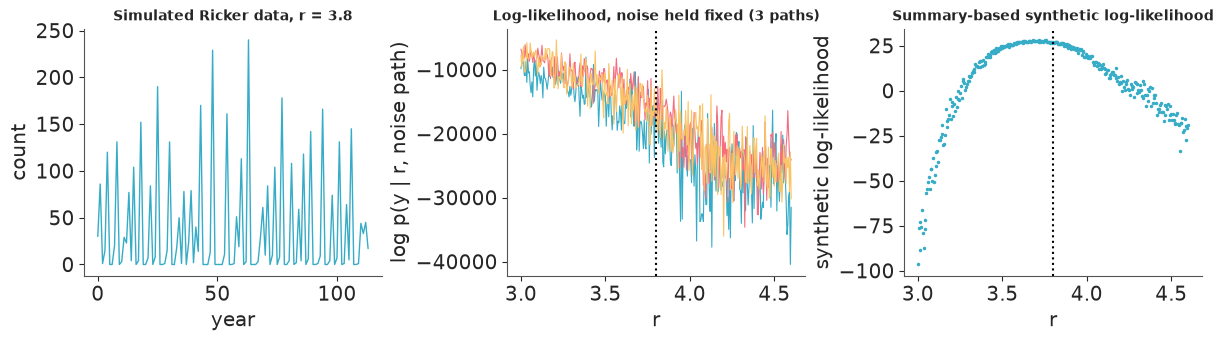

In [28]:
RICKER_W = np.array([[1.0, 0.0, 0.0]])
demo_rng = np.random.default_rng(RANDOM_SEED)
y_demo, _ = simulate_population(demo_rng, np.array([3.8]), np.array([38.0]), np.array([0.3]), RICKER_W)

r_slice = np.linspace(3.0, 4.6, 321)
n_r = len(r_slice)
ones = np.ones(n_r)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].plot(y_demo[0], lw=1)
axes[0].set(xlabel="year", ylabel="count")
axes[0].set_title("Simulated Ricker data, r = 3.8", fontsize=10)
for seed, color in zip(range(3), ["C0", "C1", "C2"]):
    fixed_noise = np.random.default_rng(seed).standard_normal((60 + T_LYNX, 1)) * ones
    _, N_path = simulate_population(demo_rng, r_slice, 38.0 * ones, 0.3 * ones, np.tile(RICKER_W, (n_r, 1)), noise=fixed_noise)
    axes[1].plot(r_slice, st.poisson.logpmf(y_demo, N_path).sum(axis=1), color=color, lw=0.8)
axes[1].axvline(3.8, color="k", ls=":")
axes[1].set(xlabel="r", ylabel="log p(y | r, noise path)")
axes[1].set_title("Log-likelihood, noise held fixed (3 paths)", fontsize=10)
sl_slice = synthetic_loglik(demo_rng, population_summaries(y_demo)[0], r_slice, 38.0 * ones, 0.3 * ones,
                            np.tile(RICKER_W, (n_r, 1)), M=300)
axes[2].plot(r_slice, sl_slice, ".", ms=3)
axes[2].axvline(3.8, color="k", ls=":")
axes[2].set(xlabel="r", ylabel="synthetic log-likelihood")
axes[2].set_title("Summary-based synthetic log-likelihood", fontsize=10);

The middle panel is why nobody fits chaotic models by matching trajectories. With the noise
held fixed the log-probability of the data jumps by thousands of log units between
neighbouring values of $r$ (chaos amplifies any change in $r$ exponentially, so the simulated
path decorrelates from the data within a few steps), for every noise path. There is nothing
there for an optimiser or a sampler to climb, nothing marks the true value (dotted line), and
the overall trend points the *wrong way*: towards small $r$, where simulated paths are tamer
and therefore miss the data by less.

The right panel asks a different question - not "does the simulated path pass through the
data?" but "does it have the same *statistical character*?" - the same mean, variability and
autocorrelation. Those are properties of the attractor, they vary smoothly with $r$, and the
resulting curve is a well-behaved function with a broad maximum that contains the truth, plus
some Monte Carlo fuzz from estimating it by simulation. **Summaries are not only a computational
compromise; for dynamics like these they are the right description of what the data can tell
you.**

### 3.3 · A first look with rejection ABC: can either model get close?

Summaries of $\log(y+1)$: mean, log standard deviation, skewness, and the autocorrelation at
lags 1-8, which encodes the period and regularity of the cycle (11 numbers). Priors, on the
log scale because all three are positive scale-like quantities:
$\log r \sim \text{Normal}(0, 1)$, which spans stable, cycling and chaotic regimes;
$\log K \sim \text{Normal}(\log 1500, 1)$, centred on the scale of the data (the mean catch is
about 1500) and spanning a factor of $e^{\pm 2}$; $\log\sigma \sim \text{Normal}(\log 0.3, 1)$; and for
the weights a logistic-Normal, $w = \text{softmax}(0, u_1, u_2)$ with $u_j \sim \text{Normal}(0, 2)$.

Step one is the 15-line algorithm from section 1, for **two models**: the plain Ricker map
($w$ fixed at $(1,0,0)$, three parameters) and the delayed model (five). 60,000 prior
simulations each, vectorised, a couple of seconds.

In [29]:
PRIOR_MEAN = np.array([0.0, np.log(1500.0), np.log(0.3), 0.0, 0.0])
PRIOR_SD = np.array([1.0, 1.0, 1.0, 2.0, 2.0])
POP_VARS = ["r", "K", "sigma", "w0", "w1", "w2"]


def unpack(theta):
    """Unconstrained (n, 3) or (n, 5) array -> r, K, sigma, w. Three columns means the plain Ricker map."""
    n = len(theta)
    if theta.shape[1] == 3:
        w = np.tile(RICKER_W, (n, 1))
    else:
        u = np.column_stack([np.zeros(n), theta[:, 3], theta[:, 4]])
        w = np.exp(u - u.max(axis=1, keepdims=True))
        w /= w.sum(axis=1, keepdims=True)
    return np.exp(theta[:, 0]), np.exp(theta[:, 1]), np.exp(theta[:, 2]), w


def log_prior(theta):
    d = theta.shape[1]
    return -0.5 * (((theta - PRIOR_MEAN[:d]) / PRIOR_SD[:d]) ** 2).sum(axis=1)


def reference_table(rng, d, n):
    theta = PRIOR_MEAN[:d] + PRIOR_SD[:d] * rng.standard_normal((n, d))
    Y, _ = simulate_population(rng, *unpack(theta))
    return theta, population_summaries(Y)


s_lynx = population_summaries(y_lynx[None])[0]
start = time.perf_counter()
theta_ricker, S_ricker = reference_table(rng, 3, 60_000)
theta_delay, S_delay = reference_table(rng, 5, 60_000)
print(f"120,000 simulated 114-year histories in {time.perf_counter() - start:.1f} s")

# one common scale for both models: robust spread (MAD) of each summary under the delayed model's prior
pop_scale = 1.4826 * np.median(np.abs(S_delay - np.median(S_delay, axis=0)), axis=0)


def scaled_distance(S):
    return np.sqrt((((S - s_lynx) / pop_scale) ** 2).mean(axis=1))


dist_ricker, dist_delay = scaled_distance(S_ricker), scaled_distance(S_delay)
N_KEEP = 300                                            # closest 0.5%
keep_ricker, keep_delay = np.argsort(dist_ricker)[:N_KEEP], np.argsort(dist_delay)[:N_KEEP]
print(f"closest the Ricker map ever gets : {dist_ricker.min():.2f}   (0.5% tolerance: {dist_ricker[keep_ricker].max():.2f})")
print(f"closest the delayed model gets   : {dist_delay.min():.2f}   (0.5% tolerance: {dist_delay[keep_delay].max():.2f})")

120,000 simulated 114-year histories in 0.9 s
closest the Ricker map ever gets : 0.62   (0.5% tolerance: 0.93)
closest the delayed model gets   : 0.15   (0.5% tolerance: 0.34)


observed peak period: 9.5 years
Ricker map    : P(predicted peak period between 8.5 and 11 years) = 0.06   median 28.5
delayed model : P(predicted peak period between 8.5 and 11 years) = 0.77   median 9.5


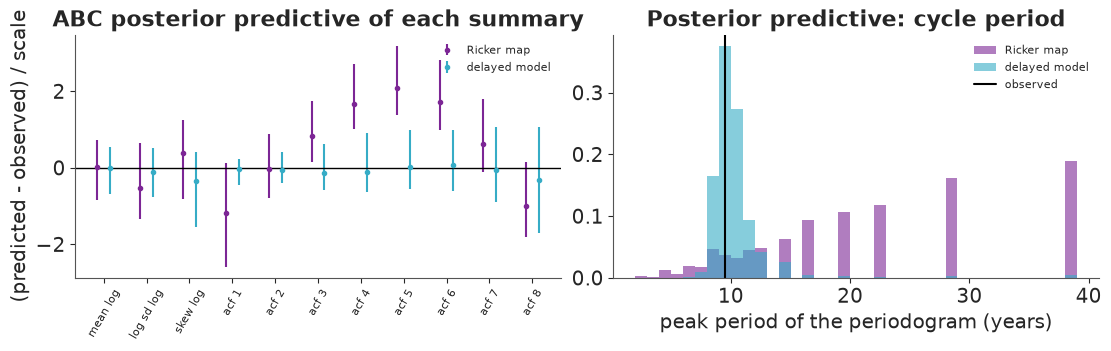

In [30]:
FREQS = np.fft.rfftfreq(T_LYNX)


def peak_period(Y):
    """Period (years) at the maximum of the periodogram of log(y + 1)."""
    L = np.log(Y + 1.0)
    power = np.abs(np.fft.rfft(L - L.mean(axis=1, keepdims=True), axis=1)) ** 2
    return 1.0 / FREQS[np.argmax(power[:, 1:], axis=1) + 1]


def predictive(rng, theta, n_rep=1000):
    idx = rng.choice(len(theta), n_rep)
    Y, _ = simulate_population(rng, *unpack(theta[idx]))
    return Y


Y_ricker_abc = predictive(rng, theta_ricker[keep_ricker])
Y_delay_abc = predictive(rng, theta_delay[keep_delay])
period_obs = peak_period(y_lynx[None])[0]
print(f"observed peak period: {period_obs:.1f} years")
for name, Y in [("Ricker map", Y_ricker_abc), ("delayed model", Y_delay_abc)]:
    per = peak_period(Y)
    print(f"{name:14s}: P(predicted peak period between 8.5 and 11 years) = {np.mean((per > 8.5) & (per < 11)):.2f}"
          f"   median {np.median(per):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x_pos = np.arange(len(SUMMARY_NAMES))
for Y, off, color, name in [(Y_ricker_abc, -0.15, "C3", "Ricker map"), (Y_delay_abc, 0.15, "C0", "delayed model")]:
    S = (population_summaries(Y) - s_lynx) / pop_scale
    lo, mid, hi = np.quantile(S, [0.05, 0.5, 0.95], axis=0)
    axes[0].errorbar(x_pos + off, mid, yerr=[mid - lo, hi - mid], fmt="o", ms=3, color=color, label=name)
axes[0].axhline(0, color="k", lw=1)
axes[0].set_xticks(x_pos, SUMMARY_NAMES, rotation=60, fontsize=8)
axes[0].set(ylabel="(predicted - observed) / scale", title="ABC posterior predictive of each summary")
axes[0].legend(fontsize=8)
bins = np.arange(2, 40, 1.0)
axes[1].hist(peak_period(Y_ricker_abc), bins=bins, alpha=0.6, color="C3", density=True, label="Ricker map")
axes[1].hist(peak_period(Y_delay_abc), bins=bins, alpha=0.6, color="C0", density=True, label="delayed model")
axes[1].axvline(period_obs, color="k", label="observed")
axes[1].set(xlabel="peak period of the periodogram (years)", title="Posterior predictive: cycle period")
axes[1].legend(fontsize=8);

**The stochastic Ricker map cannot produce the lynx cycle, and the SBI analysis says so in
three ways.** In 60,000 draws across its whole prior - stable, period-doubling and chaotic
regimes - its closest approach to the observed summaries is several times further away than
the delayed model's. Its posterior predictive misses the autocorrelations systematically: too
little correlation at lag 1, none of the negative correlation at the half-period (lags 4-6),
and no rebound at lag 8. And it puts only a
few percent of its predictive mass on a period near ten years, against a large majority for
the delayed model (the peak period was *not* one of the summaries, so that is an out-of-sample
check of sorts).

This is worth dwelling on. An ABC run always returns *a* posterior: the 300 "best" draws of a
wrong model look like any other 300 draws. The protection is to **look at the distances and
at the posterior predictive of the summaries**. A model whose best simulations are still far
from the data is the wrong model, and that is a legitimate scientific finding: ten-year
cycles need delayed density dependence - an interaction with something unobserved.

### 3.4 · Sharpening the delayed model: synthetic likelihood

Rejection ABC with 11 summaries and a 0.5% acceptance quantile is a blunt instrument (the
tolerance is large: recall 2.5). Wood's (2010) **synthetic likelihood** removes the tolerance
altogether. At each $\theta$: run $M$ simulations, compute their summaries, fit a multivariate
Normal to them, and evaluate the observed summaries under it,

$$
\log L_s(\theta) = -\tfrac12 \big(s^{\text{obs}} - \hat\mu_\theta\big)^\top \hat\Sigma_\theta^{-1} \big(s^{\text{obs}} - \hat\mu_\theta\big) - \tfrac12 \log\lvert\hat\Sigma_\theta\rvert .
$$

The $\epsilon$ approximation is replaced by a **Normality assumption on the summaries** (central
limit behaviour makes it reasonable for averages like autocorrelations), correlations between
summaries are handled by $\hat\Sigma_\theta$ rather than by ad-hoc scaling, and the cost is $M$
simulations per evaluation. It is the function plotted in the right panel of 3.2.

Wood explored it with Metropolis-Hastings. Because our simulator is vectorised, **adaptive
importance sampling** is a better fit: draw 2000 $\theta$ from a multivariate-t proposal,
evaluate all of them in a few NumPy calls (2000 x 200 simulated histories per round),
weight by prior x synthetic likelihood / proposal, refit the proposal to the weighted
sample, repeat. The first proposal is fitted to the ABC draws of 3.3, which is what cheap ABC
is best at - finding the neighbourhood. The last three rounds are pooled.

In [31]:
def adaptive_importance_sampling(rng, mean, cov, n=2000, rounds=5, pool=3, M=200, df=5, inflate=2.0):
    d = len(mean)
    thetas, logws, log = [], [], []
    for k in range(rounds):
        proposal = st.multivariate_t(mean, inflate * cov, df=df)
        theta = proposal.rvs(n, random_state=rng)
        logw = synthetic_loglik(rng, s_lynx, *unpack(theta), M=M) + log_prior(theta) - proposal.logpdf(theta)
        logw = np.where(np.isfinite(logw), logw, -np.inf)
        wgt = np.exp(logw - logw.max())
        wgt /= wgt.sum()
        mean = wgt @ theta
        cov = (theta - mean).T @ ((theta - mean) * wgt[:, None]) + 1e-8 * np.eye(d)
        log.append({"round": k, "ESS": 1 / np.sum(wgt**2), "max log weight": logw.max()})
        thetas.append(theta)
        logws.append(logw)
    theta, logw = np.concatenate(thetas[-pool:]), np.concatenate(logws[-pool:])
    wgt = np.exp(logw - logw.max())
    return theta, wgt / wgt.sum(), pd.DataFrame(log).set_index("round")


start = time.perf_counter()
theta_sl, w_sl, ais_log = adaptive_importance_sampling(
    rng, theta_delay[keep_delay].mean(axis=0), np.cov(theta_delay[keep_delay].T))
ess_pooled = 1 / np.sum(w_sl**2)
print(f"{time.perf_counter() - start:.0f} s; pooled ESS of the last three rounds: {ess_pooled:.0f} of {len(w_sl)}")
ais_log.round(1)

14 s; pooled ESS of the last three rounds: 552 of 6000


,ESS,max log weight
round,,
0,3.1,31.3
1,13.9,30.0
2,156.0,28.4
3,194.8,27.8
4,249.2,27.3


The ESS is the diagnostic to watch. It climbs steeply as the proposal adapts and then creeps
along at around a tenth of the draws. Part of that is proposal mismatch; part is irreducible at
this $M$: the synthetic log-likelihood is itself a noisy estimate (its standard deviation at a
fixed $\theta$ is measured below), and noisy weights cost ESS. A pooled ESS of a few hundred
supports means, standard deviations and central intervals - not far-tail statements.

In [32]:
def weighted_summary(theta, w):
    r, K, sigma, wts = unpack(theta)
    cols = np.column_stack([r, K, sigma, wts])
    out = {}
    for j, name in enumerate(POP_VARS):
        order = np.argsort(cols[:, j])
        cdf = np.cumsum(w[order])
        lo, hi = cols[order, j][np.searchsorted(cdf, [0.03, 0.97])]
        m = w @ cols[:, j]
        out[name] = {"mean": m, "sd": np.sqrt(w @ (cols[:, j] - m) ** 2), "3%": lo, "97%": hi}
    return pd.DataFrame(out).T


uniform_w = np.full(N_KEEP, 1 / N_KEEP)
pd.concat({"rejection ABC (0.5%)": weighted_summary(theta_delay[keep_delay], uniform_w),
           "synthetic likelihood": weighted_summary(theta_sl, w_sl)}, axis=1).round(3)

rejection ABC (0.5%)                              synthetic likelihood  \
                      mean        sd       3%       97%                 mean   
r                    0.935     0.306    0.548     1.658                0.830   
K                 2179.031  2258.403  363.382  8475.658             1518.951   
sigma                0.262     0.104    0.127     0.506                0.379   
w0                   0.133     0.072    0.022     0.294                0.140   
w1                   0.116     0.118    0.003     0.436                0.220   
w2                   0.751     0.116    0.475     0.939                0.640   

                                   
           sd        3%       97%  
r       0.077     0.680     0.981  
K      97.407  1343.074  1715.949  
sigma   0.060     0.273     0.506  
w0      0.073     0.025     0.285  
w1      0.150     0.011     0.517  
w2      0.115     0.409     0.838

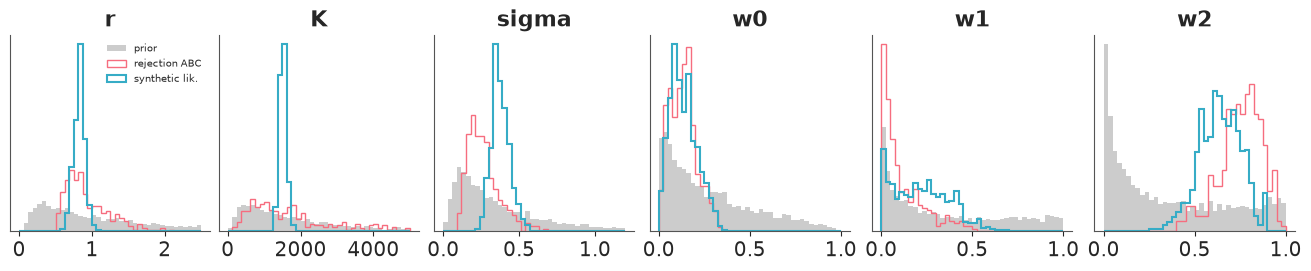

In [33]:
resample = rng.choice(len(w_sl), 4000, p=w_sl)
post_sl = np.column_stack([*unpack(theta_sl[resample])[:3], unpack(theta_sl[resample])[3]])
post_abc = np.column_stack([*unpack(theta_delay[keep_delay])[:3], unpack(theta_delay[keep_delay])[3]])
prior_draws = PRIOR_MEAN + PRIOR_SD * rng.standard_normal((4000, 5))
post_prior = np.column_stack([*unpack(prior_draws)[:3], unpack(prior_draws)[3]])

fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
ranges = [(0, 2.5), (0, 5000), (0, 1.2), (0, 1), (0, 1), (0, 1)]
for ax, j, rg in zip(axes, range(6), ranges):
    ax.hist(post_prior[:, j], bins=40, range=rg, density=True, color="0.8", label="prior")
    ax.hist(post_abc[:, j], bins=40, range=rg, density=True, histtype="step", color="C1", label="rejection ABC")
    ax.hist(post_sl[:, j], bins=40, range=rg, density=True, histtype="step", color="C0", lw=1.5, label="synthetic lik.")
    ax.set(title=POP_VARS[j], yticks=[])
axes[0].legend(fontsize=7);

Two likelihood-free methods, the same summaries:

- They **agree on the story**: growth rate $r$ somewhat below one, most of the density
  dependence at lag two ($w_2$ is the largest weight under both), little at lag zero. They
  differ somewhat on the noise level $\sigma$ (0.26 against 0.38, about one ABC standard
  deviation).
- Synthetic likelihood is **much sharper** - dramatically so for $K$, where the ABC answer is
  barely narrower than its prior, and substantially for $r$ and $\sigma$. That is the
  $\epsilon$-error of section 1 showing up at full scale: eleven summaries, a 0.5% acceptance
  quantile, and the accepted simulations are simply not very close. SMC-ABC would narrow the
  gap; it would not close it for the reason seen in 2.5.
- The price of that sharpness is the Normality assumption. A quick look at the simulated
  summaries near the posterior mean:

In [34]:
theta_hat = (w_sl @ theta_sl)[None, :]
Y_hat, _ = simulate_population(rng, *(np.repeat(a, 2000, axis=0) for a in unpack(theta_hat)))
S_hat = population_summaries(Y_hat)
sl_repeats = synthetic_loglik(rng, s_lynx, *(np.repeat(a, 50, axis=0) for a in unpack(theta_hat)))
print(f"sd of the synthetic log-likelihood over 50 repeats at the same theta (M = 200): {sl_repeats.std():.2f}")
del Y_hat
pd.DataFrame({"skewness": st.skew(S_hat), "excess kurtosis": st.kurtosis(S_hat),
              "observed, in sd's from the simulated mean": (s_lynx - S_hat.mean(0)) / S_hat.std(0)},
             index=SUMMARY_NAMES).round(2).T

sd of the synthetic log-likelihood over 50 repeats at the same theta (M = 200): 0.85


,mean log,log sd log,skew log,acf 1,acf 2,acf 3,acf 4,acf 5,acf 6,acf 7,acf 8
skewness,-0.73,-0.05,-0.9,-0.21,0.39,0.68,0.98,1.22,0.83,0.36,0.23
excess kurtosis,0.96,-0.11,0.8,0.47,0.40,0.67,1.32,2.39,2.12,0.29,-0.18
"observed, in sd's from the simulated mean",-0.66,0.45,1.4,0.11,-0.26,-0.31,-0.70,-1.12,-1.23,-0.19,1.05


The summaries are not exactly Normal - the autocorrelations at lags 4-6 have a skewness around
one and an excess kurtosis between one and two and a half, and the mean and skewness statistics are skewed the
other way - but nothing is wildly off, and every observed summary sits within one and a half
standard deviations of the simulated mean. Synthetic likelihood is known to be fairly forgiving of this degree of
non-Normality (Price, Drovandi, Lee & Nott 2018), and the agreement in location with
rejection ABC, which makes no such assumption, is some reassurance. A transformation of the
offending summaries would be the next refinement.

### 3.5 · Posterior predictive check: period, amplitude, and what is still wrong

period   : observed 9.5, predictive median 9.5, P(8.5 < period < 11) = 0.66
amplitude: observed 2.25, predictive 5-95%: 1.51 to 3.65
skewness : observed -0.36, P(predicted < observed) = 0.91


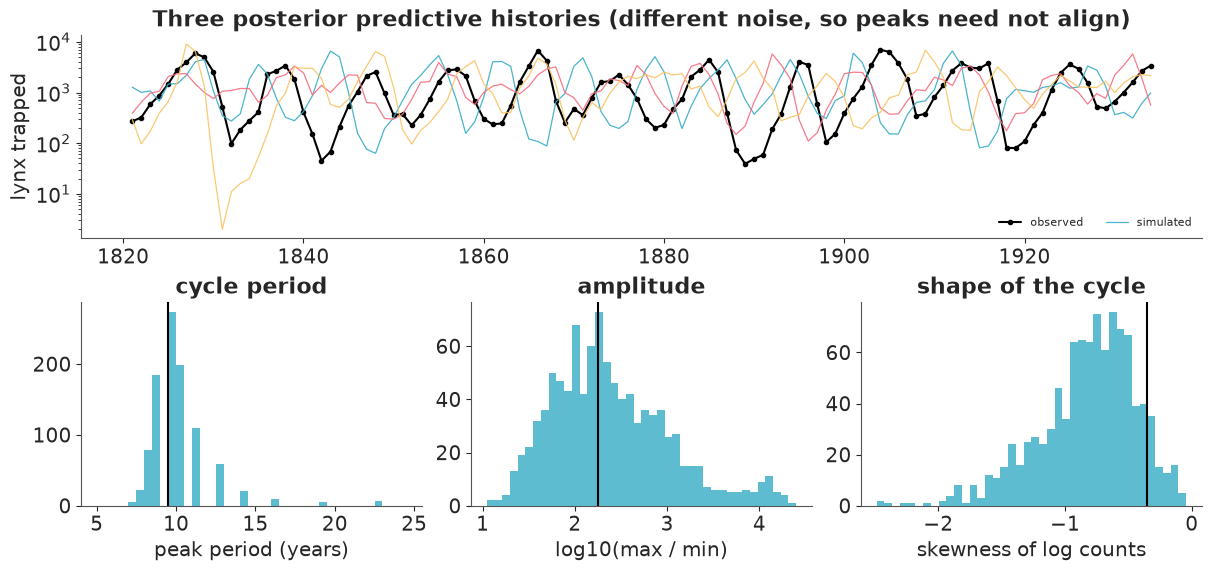

In [35]:
Y_sl = predictive(rng, theta_sl[resample])
per_sl = peak_period(Y_sl)
amp_obs = np.log10(y_lynx.max() / y_lynx.min())
amp_sl = np.log10((Y_sl.max(axis=1) + 1) / (Y_sl.min(axis=1) + 1))

fig = plt.figure(figsize=(12, 5.6))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :])
ax.plot(lynx["time"], y_lynx, "k.-", lw=1.5, label="observed")
for i, color in enumerate(["C0", "C1", "C2"]):
    ax.plot(lynx["time"], Y_sl[i] + 1, color=color, lw=0.9, alpha=0.9, label="simulated" if i == 0 else None)
ax.set(yscale="log", ylabel="lynx trapped", title="Three posterior predictive histories (different noise, so peaks need not align)")
ax.legend(fontsize=8, ncol=2)

ax = fig.add_subplot(gs[1, 0])
ax.hist(per_sl, bins=np.arange(5, 25, 0.5), color="C0", alpha=0.8)
ax.axvline(period_obs, color="k")
ax.set(xlabel="peak period (years)", title="cycle period")
ax = fig.add_subplot(gs[1, 1])
ax.hist(amp_sl, bins=40, color="C0", alpha=0.8)
ax.axvline(amp_obs, color="k")
ax.set(xlabel="log10(max / min)", title="amplitude")
ax = fig.add_subplot(gs[1, 2])
sk = population_summaries(Y_sl)[:, 2]
ax.hist(sk, bins=40, color="C0", alpha=0.8)
ax.axvline(s_lynx[2], color="k")
ax.set(xlabel="skewness of log counts", title="shape of the cycle")

print(f"period   : observed {period_obs:.1f}, predictive median {np.median(per_sl):.1f},"
      f" P(8.5 < period < 11) = {np.mean((per_sl > 8.5) & (per_sl < 11)):.2f}")
print(f"amplitude: observed {amp_obs:.2f}, predictive 5-95%: {np.quantile(amp_sl, 0.05):.2f} to {np.quantile(amp_sl, 0.95):.2f}")
print(f"skewness : observed {s_lynx[2]:.2f}, P(predicted < observed) = {np.mean(sk < s_lynx[2]):.2f}");

- **Period.** About two thirds of the predictive mass is within a year or so of the observed
  9.5 years, which is also the predictive median (the
  periodogram of a 114-year series only resolves periods of 114/$j$ years: ..., 8.8, 9.5, 10.4,
  11.4, ..., hence the comb). The periodogram peak was not a fitted summary.
- **Amplitude.** Observed max/min ratio comfortably inside the predictive range.
- **Regularity.** Look at the top panel: the real series is more clock-like than the simulated
  ones, whose cycles wander in length and height. The summaries said the same thing in the
  table of 3.4 - the observed autocorrelations at lags 5, 6 and 8 are all about one standard
  deviation more extreme than the model's average. Each is unremarkable alone; together they
  point one way.
- **Shape.** The one visible discrepancy: simulated log-counts are more negatively skewed than
  the real ones - the model's crashes are deeper and sharper than the lynx's, whose troughs are
  comparatively shallow. The observed value is in the upper tail of the predictive
  distribution (around the 90th percentile), not outside it, but it points at the functional form: Ricker-style
  exponential density dependence is a strong assumption about how crashes happen.

**What kind of cycle is it?** Linearising the noise-free map about $N = K$ gives the
characteristic polynomial $\lambda^3 - (1 - r w_0)\lambda^2 + r w_1 \lambda + r w_2 = 0$. If the
largest root has modulus above one, the deterministic skeleton cycles on its own (a limit
cycle); below one, it spirals into $K$ and only the noise keeps the oscillation alive. The
angle of that root gives the period of the oscillation. For every posterior draw:

In [36]:
r_post, _, _, w_post = unpack(theta_sl[resample])
roots = np.array([np.roots([1.0, -(1 - r * w[0]), r * w[1], r * w[2]]) for r, w in zip(r_post, w_post)])
lead = roots[np.arange(len(roots)), np.argmax(np.abs(roots), axis=1)]
modulus, linear_period = np.abs(lead), 2 * np.pi / np.abs(np.angle(lead))
print(f"modulus of the leading root : median {np.median(modulus):.2f}, 3-97%: {np.quantile(modulus, 0.03):.2f}"
      f" to {np.quantile(modulus, 0.97):.2f};  P(modulus > 1) = {np.mean(modulus > 1):.2f}")
print(f"period of the linearised map: median {np.median(linear_period):.1f} years, 3-97%:"
      f" {np.quantile(linear_period, 0.03):.1f} to {np.quantile(linear_period, 0.97):.1f}")

modulus of the leading root : median 0.99, 3-97%: 0.91 to 1.03;  P(modulus > 1) = 0.29
period of the linearised map: median 8.3 years, 3-97%: 7.6 to 9.1


**The scientific reading.** The posterior puts the density dependence mostly at a lag of two
years, with the undelayed Ricker term $w_0$ small. The leading root sits almost exactly on the
unit circle - median modulus 0.99, with roughly 70% of the posterior on the stable side and
30% on the cycling side. So the data place the lynx **at the edge of the cycling threshold**,
and this analysis cannot tell a weakly damped oscillation kept alive by environmental noise
from a weak limit cycle blurred by it. What it does exclude is everything far from that edge:
a strongly stable population, and the period-doubling and chaotic regimes of the Ricker map.
Notice also that the linearised period (about 8 years) is shorter than the 9.5 years at which
the full noisy, nonlinear simulations from the same posterior peak - one more thing you only
learn by simulating. A single-species model cannot say *what* carries the two-year memory;
ecology says hares and vegetation. All of this was obtained without ever evaluating a
likelihood.

One caveat belongs here: both methods condition on 11 summaries of a 114-point series. A
particle-filter likelihood on the full series would use more information and might be
sharper - and, in the near-chaotic corners of parameter space, might not work at all.

## 4 · A checklist of SBI-specific diagnostics

Ordinary MCMC diagnostics tell you whether you sampled *the target*. In SBI the target itself
is an approximation, so add these, all of which appeared above:

| Question | Check | Where |
|---|---|---|
| Does the inference machine work at all? | Recover a **known posterior** on a toy, including the *predicted* size of the $\epsilon$-error | 1.1, 1.3 |
| Is $\epsilon$ small enough? | Re-run with a different $\epsilon$; compare widths. Think of $\epsilon$ in units of the summaries' sampling sd | 1.1, 2.5 |
| Did SMC-ABC degenerate? | **Acceptance rate per stage**, `r_hat`/ESS *across independent runs*; acceptance near 1% means the particles have stopped moving | 2.3, 2.5 |
| Is importance sampling reliable? | **ESS of the weights** per round | 3.4 |
| Are the intervals calibrated? | **Coverage / SBC** on simulated datasets - catches $\epsilon$-error and bugs | 1.4 |
| Did the summaries lose information? | Coverage **cannot** tell you. Compare widths across summary sets, or against a reference posterior when one can be had | 1.2, 1.4, 2.4, 2.6 |
| Do the summaries pick the right features? | Under misspecification different summaries give different answers: choose them for the purpose, and **say which you used** | 2.6, 2.7 |
| Can the model reach the data at all? | **Smallest distance achieved**, posterior predictive of the summaries, and a held-out statistic | 3.3, 3.5 |
| Is the synthetic likelihood's assumption tenable? | Skewness/kurtosis of simulated summaries; agreement with a tolerance-based method | 3.4 |

A full SBC for the SMC-ABC fits of section 2 would mean hundreds of 10-second runs - the
better part of an hour, not of a minute - so it was run on the toy only. That cost is the strongest practical argument
for the methods in the next section.

## 5 · Where the frontier is now

Classical ABC, as used here, has a design flaw: every simulation that is rejected is thrown
away, and every new dataset starts from scratch. The last decade of SBI research (surveyed by
Cranmer, Brehmer & Louppe 2020, "The frontier of simulation-based inference") replaces the
accept/reject step with **a neural density estimator trained on the simulations**:

- **Neural posterior estimation (NPE).** Simulate pairs $(\theta_i, y_i)$ from the prior and the
  simulator; train a conditional normalising flow $q_\phi(\theta \mid y)$ to maximise
  $\sum_i \log q_\phi(\theta_i \mid y_i)$. At the optimum $q_\phi$ *is* the posterior, for every $y$ at
  once. No tolerance, no rejected simulations. Sequential variants (Papamakarios & Murray 2016;
  Greenberg et al. 2019) focus simulations on the observed data.
- **Neural likelihood / ratio estimation (NLE, NRE).** Learn $p(y \mid \theta)$ or the ratio
  $p(y \mid \theta)/p(y)$ instead, then run ordinary MCMC on the learned surrogate. Synthetic
  likelihood is the ancestor: a Gaussian is the simplest possible conditional density model.
- **Amortisation.** Once trained, inference for a new dataset is a forward pass -
  milliseconds. That makes the coverage tests of 1.4 essentially free, and makes SBI viable
  inside a loop (thousands of gravitational-wave events, per-subject cognitive models).
- **Learned summary statistics.** An embedding network trained jointly with the flow replaces
  hand-chosen summaries; with enough simulations it approaches sufficiency. The classical
  precursor regresses $\theta$ on candidate summaries (Fearnhead & Prangle 2012).

The standard packages are **`sbi`** (PyTorch) and **BayesFlow**. Neither is installed in this
environment and this notebook deliberately contains no code it cannot run. (flowjax *is*
installed, so an NPE in JAX is possible - but not in the same process as `pm.sample_smc`; see
the fork gotcha.)

Be as sceptical of the neural methods as this notebook was of ABC. A flow can be confidently
wrong where training simulations were sparse; reported posteriors are often *over*confident
(Hermans et al. 2022), the opposite of ABC's conservative $\epsilon$-error; learned summaries
are as exposed to model misspecification as hand-made ones, without the option of reading them;
and training needs $10^4$-$10^6$ simulations up front. Coverage tests are not optional there.

**When classical ABC or synthetic likelihood is still the right tool:** the simulator is
expensive and you can afford thousands of runs rather than hundreds of thousands, focused on
one dataset; you have few parameters and good, interpretable summaries (section 3 was solved in
half a minute of NumPy); you need to *choose* which features of the data the fit honours
(section 2); or you need a method whose every approximation you can state in one sentence and
check in one table.

In [37]:
print(f"notebook run time: {time.perf_counter() - NOTEBOOK_START:.0f} s")

notebook run time: 73 s


### Try it yourself

1. **Regression adjustment.** In section 1.2 the accepted draws with a sloppy tolerance (keep
   the closest 20%) are far too wide. Regress the accepted $\mu$ on the accepted summaries
   ($\mu_i = a + b^\top (s_i - s^{\text{obs}}) + \text{residual}$) and replace each draw by
   $\mu_i - b^\top (s_i - s^{\text{obs}})$ (Beaumont, Zhang & Balding 2002). How much of the
   $\epsilon$-error does that remove, and what does the coverage test of 1.4 say afterwards?
   Then try it on the lynx rejection-ABC draws of 3.3 and compare with the synthetic-likelihood
   posterior.
2. **A different question of the same returns.** Refit the g-and-k model with
   `s_tail_quantiles` on the *first* and *second* halves of the sample separately (2008-2013
   and 2014-2019). Which parameters move? Does the 1% quantile differ by more than its posterior
   uncertainty? What does that say about treating twelve years of returns as exchangeable?
3. **SMC-ABC for the lynx.** Wrap `simulate_population` + `population_summaries` in a
   `pm.Simulator` (use `pm.Dirichlet` for $w$) with $\epsilon_j$ set to the standard deviations
   in `S_hat`, and run `pm.sample_smc`. Watch the per-stage acceptance rate with 11 summaries.
   Then drop to the 5 or 6 summaries you think matter most. Where does the posterior land
   relative to rejection ABC and synthetic likelihood - and which of the three would you put in
   a paper?

Next: **E09** if you skipped it (the deterministic cousin of section 3, with gradients), or
**E12** for approximate inference when you *do* have a likelihood but it is expensive.